# Upworthy Empirical A/B Study

This notebook analyzes the Upworthy empirical A/B test run in `results/empirical_study/upworthy/upworthy_empirical_ab_20260721_103812`, using the $m$-out-of-$n$ hyperparameter $m=\lfloor N^{0.6}\rfloor$. The paper-facing message is simple: in real multi-arm click-through-rate tests, the selected winner's observed CTR is systematically overestimated because the same noisy data are used to choose and evaluate the winner.

The notebook does not rerun any estimators. It loads the saved per-test estimates, summary tables, arm-level input, run manifest, and Monte Carlo draw arrays, then builds exploratory figures and tables for the empirical section.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

# Resolve paths whether the notebook is executed from the repo root or notebooks/.
CWD = Path.cwd().resolve()
if (CWD / "pyproject.toml").exists() and (CWD / "notebooks").exists():
    PROJECT_ROOT = CWD
    NOTEBOOK_DIR = CWD / "notebooks"
elif CWD.name == "notebooks" and (CWD.parent / "pyproject.toml").exists():
    NOTEBOOK_DIR = CWD
    PROJECT_ROOT = CWD.parent
else:
    PROJECT_ROOT = Path("/Users/iamsikun/research/winners-curse").resolve()
    NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

RESULT_DIR = PROJECT_ROOT / "results" / "empirical_study" / "upworthy" / "upworthy_empirical_ab_20260721_103812"
DATASET_DOC = PROJECT_ROOT / "docs" / "upworthy-dataset.html"
PAPER_PATH = PROJECT_ROOT / "docs" / "mnsc" / "paper.pdf"
AUDIT_SUMMARY_PATH = PROJECT_ROOT / "dataset" / "upworthy" / "derived" / "audit-summary.json"

SAVE_ARTIFACTS = True
PUBLIC_ARTIFACT_DIRS = [
    PROJECT_ROOT / "docs" / "assets" / "upworthy",
    PROJECT_ROOT / "paper" / "journal" / "figures" / "upworthy",
    PROJECT_ROOT / "docs" / "Winner_s_Curse_in_Personalized_Targeting" / "figures" / "upworthy",
]
PUBLIC_ARTIFACT_FILES = {
    "bias_by_snr": "bias-by-snr.png",
    "bias_by_arm_count": "bias-by-arm-count.png",
    "bias_by_total_impressions": "bias-by-total-impressions.png",
    "heatmap_bias_snr_arm_count": "heatmap-bias-snr-arm-count.png",
    "snr_distribution": "snr-distribution-histogram.png",
    "winner_runner_up_gap_distribution": "winner-runner-up-gap-histogram.png",
    "impressions-per-arm": "impressions-per-arm-histogram.png",
    "headline_naive_vs_corrected_ctr": "headline-naive-vs-corrected-ctr.png",
    "dataset_context": "dataset-context.png",
    "winner_curse_distribution": "winner-curse-distribution.png",
    "moon_bias_scatter_by_snr": "moon-bias-scatter-by-snr.png",
    "moon_bias_scatter_by_total_impressions": "moon-bias-scatter-by-total-impressions.png",
}

ESTIMATORS = [
    "standard_bootstrap",
    "moon_bootstrap",
    "sample_splitting",
    "eb_normal",
    "hybrid_si",
]
ESTIMATOR_LABELS = {
    "standard_bootstrap": "Standard Bootstrap",
    "moon_bootstrap": "$m$-out-of-$n$ Bootstrap ($\\gamma=0.6$)",
    "sample_splitting": "Sample Splitting",
    "eb_normal": "Empirical Bayes",
    "hybrid_si": "Hybrid Selective Inference",
}
PRIMARY_ESTIMATORS = ["standard_bootstrap", "moon_bootstrap"]
MOON_PLOT_LABEL = "$m$-out-of-$n$ Bootstrap"
PRIMARY_LINESTYLES = {
    ESTIMATOR_LABELS["standard_bootstrap"]: "-",
    ESTIMATOR_LABELS["moon_bootstrap"]: "--",
}
ARM_BIN_ORDER = ["2", "3", "4", "5", "6-7", "8+"]
SNR_DECILE_LABELS = [f"{i * 10}-{(i + 1) * 10}%" for i in range(10)]

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.titleweight": "bold",
    "axes.labelsize": 14,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})
ANNOTATION_FONT_SIZE = plt.rcParams["legend.fontsize"]


def save_fig(fig: plt.Figure, name: str) -> None:
    """Optionally save a figure as PNG and PDF for paper drafting."""
    if not SAVE_ARTIFACTS:
        return
    public_filename = PUBLIC_ARTIFACT_FILES.get(name)
    if public_filename is None:
        return
    for artifact_dir in PUBLIC_ARTIFACT_DIRS:
        artifact_dir.mkdir(parents=True, exist_ok=True)
        png_path = artifact_dir / public_filename
        fig.savefig(png_path, bbox_inches="tight")
        fig.savefig(png_path.with_suffix(".pdf"), bbox_inches="tight")


def pct(x: pd.Series | float) -> pd.Series | float:
    """Convert a rate to percent units."""
    return x * 100


print(f"Project root: {PROJECT_ROOT}")
print(f"Result dir:   {RESULT_DIR}")

Project root: /Users/iamsikun/research/winners-curse
Result dir:   /Users/iamsikun/research/winners-curse/results/empirical_study/upworthy/upworthy_empirical_ab_20260721_103812


## Load Saved Artifacts

The empirical run already computed the estimator corrections for each Upworthy test. The cells below only load and reshape the saved artifacts.

In [2]:
per_test = pd.read_csv(RESULT_DIR / "per_test_estimates.csv.gz")
summary_tables = pd.read_csv(RESULT_DIR / "summary_tables.csv")
arm_level = pd.read_csv(RESULT_DIR / "arm_level_input.csv.gz")

with (RESULT_DIR / "summary.json").open() as handle:
    summary_json = json.load(handle)
with (RESULT_DIR / "run_manifest.json").open() as handle:
    run_manifest = json.load(handle)
with AUDIT_SUMMARY_PATH.open() as handle:
    audit_summary = json.load(handle)

estimator_draws = np.load(RESULT_DIR / "estimator_draws.npz")
available_estimators = [e for e in ESTIMATORS if f"{e}_estimated_bias" in per_test.columns]

run_overview = pd.DataFrame(
    [
        {"item": "Result run", "value": RESULT_DIR.name},
        {"item": "Input file", "value": Path(run_manifest["input_path"]).name},
        {"item": "Input SHA-256", "value": run_manifest["input_sha256"][:16] + "..."},
        {"item": "Run completed", "value": run_manifest["completed_at"]},
        {"item": "Tests run", "value": f"{run_manifest['n_tests_run']:,}"},
        {"item": "Estimators", "value": ", ".join(ESTIMATOR_LABELS[e] for e in available_estimators)},
        {"item": "Bootstrap draws", "value": f"{run_manifest['parameters']['n_bootstraps']:,}"},
        {"item": "Sample splits", "value": f"{run_manifest['parameters']['n_sample_splits']:,}"},
        {"item": "$m$-out-of-$n$ Power", "value": run_manifest["parameters"]["moon_power"]},
    ]
)
display(run_overview)

print("Per-test estimates:", per_test.shape)
print("Arm-level input:", arm_level.shape)
print("Summary table rows:", summary_tables.shape[0])
print("Draw arrays:", {key: estimator_draws[key].shape for key in estimator_draws.files})

/var/folders/3l/3v_7k8t579j60k6cv9rj77080000gn/T/ipykernel_64080/658786752.py:3: DtypeWarning: Columns (0: share_text, 1: square) have mixed types. Specify dtype option on import or set low_memory=False.
  arm_level = pd.read_csv(RESULT_DIR / "arm_level_input.csv.gz")


,item,value
0,Result run,upworthy_empirical_ab_20260721_103812
1,Input file,deployed-arm-audit.csv
2,Input SHA-256,7b54a85192c510a7...
3,Run completed,2026-07-21T10:39:22
4,Tests run,"32,389"
5,Estimators,"Standard Bootstrap, $m$-out-of-$n$ Bootstrap (..."
6,Bootstrap draws,"1,000"
7,Sample splits,"1,000"
8,$m$-out-of-$n$ Power,0.6


Per-test estimates: (32389, 68)
Arm-level input: (150408, 22)
Summary table rows: 90


Draw arrays: {'moon_bootstrap_bias': (32389, 1000), 'moon_bootstrap_selected_arm': (32389, 1000), 'sample_splitting_selected_arm': (32389, 1000), 'sample_splitting_validation_ctr': (32389, 1000), 'standard_bootstrap_bias': (32389, 1000), 'standard_bootstrap_selected_arm': (32389, 1000), 'test_ids': (32389,)}


## Empirical Framing For The Paper

The Upworthy archive contains deployed headline and content experiments from a real high-volume media testing environment. An arm is a tested combination of headline, lede or subheading, social-preview text, and image identifiers within one `clickability_test_id`.

Paper wording should stay close to the public data: the outcome is click probability or click-through rate, computed as `clicks / impressions`. The archive provides aggregate clicks and impressions at the arm level, not viewer-level behavior after the click. The identifying issue for this section is not confounding across observed user traits; it is selection over noisy realized CTRs within randomized multi-arm tests.

The empirical selection rule used here is the paper's inference-then-optimization rule: choose the arm with the largest observed CTR within each test, then ask how much that selected winner's CTR is overstated after noisy selection.

In [3]:
dataset_context = pd.DataFrame(
    [
        {
            "quantity": "Deployed tests in archive",
            "value": f"{audit_summary['deployed_totals']['tests']:,}",
            "source": "dataset audit / docs/upworthy-dataset.html",
        },
        {
            "quantity": "Deployed Arms In Archive",
            "value": f"{audit_summary['deployed_totals']['arms']:,}",
            "source": "dataset audit / docs/upworthy-dataset.html",
        },
        {
            "quantity": "Recorded impressions",
            "value": f"{audit_summary['deployed_totals']['impressions']:,}",
            "source": "dataset audit / docs/upworthy-dataset.html",
        },
        {
            "quantity": "Weighted archive CTR",
            "value": f"{pct(audit_summary['deployed_totals']['weighted_click_rate']):.2f}%",
            "source": "clicks / impressions",
        },
        {
            "quantity": "Eligible tests in empirical run",
            "value": f"{run_manifest['eligibility']['eligible_tests']:,}",
            "source": "run_manifest.json",
        },
        {
            "quantity": "Eligible arms in empirical run",
            "value": f"{int(per_test['n_arms'].sum()):,}",
            "source": "per_test_estimates.csv.gz",
        },
        {
            "quantity": "Median arms per eligible test",
            "value": f"{per_test['n_arms'].median():.0f}",
            "source": "per_test_estimates.csv.gz",
        },
        {
            "quantity": "Median impressions per eligible test",
            "value": f"{per_test['total_impressions'].median():,.0f}",
            "source": "per_test_estimates.csv.gz",
        },
    ]
)
display(dataset_context)

eligibility = pd.Series(run_manifest["eligibility"]).rename("count").to_frame()
display(eligibility)

,quantity,value,source
0,Deployed tests in archive,"32,487",dataset audit / docs/upworthy-dataset.html
1,Deployed Arms In Archive,"150,817",dataset audit / docs/upworthy-dataset.html
2,Recorded impressions,"538,272,878",dataset audit / docs/upworthy-dataset.html
3,Weighted archive CTR,1.52%,clicks / impressions
4,Eligible tests in empirical run,"32,389",run_manifest.json
5,Eligible arms in empirical run,"150,408",per_test_estimates.csv.gz
6,Median arms per eligible test,4,per_test_estimates.csv.gz
7,Median impressions per eligible test,"14,353",per_test_estimates.csv.gz


,count
eligible_tests,32389
excluded_min_impressions_tests,96
excluded_single_arm_tests,2
excluded_tests,98
min_arms,2
min_impressions,1000
total_tests,32487


## Pre-Cutoff Package-Arm Impressions

This section summarizes and plots impressions per package arm before applying the 1,000-impression-per-arm cutoff.

statistic,impressions
Mean,"3,569.38"
Minimum,2.00
25th percentile,"2,745.00"
Median,"3,117.00"
75th percentile,"4,089.00"
Maximum,"36,908.00"


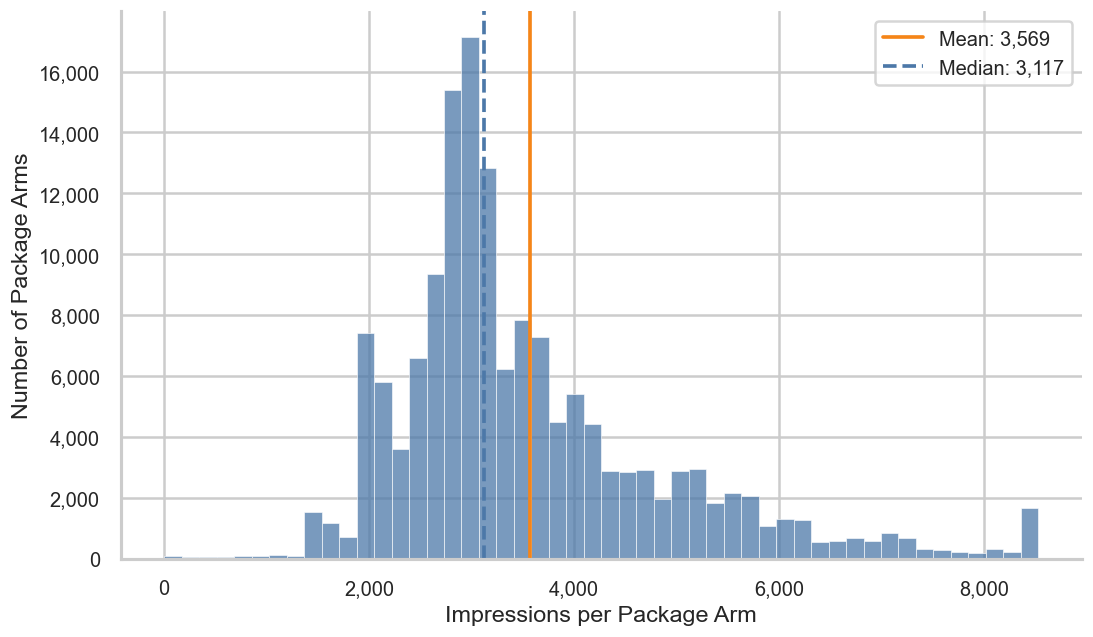

Figure note: this is the pre-cutoff sample of 150,803 arms in 32,481 tests. The rightmost bin includes arms at or above the 99th percentile (8,530 impressions).

In [4]:
# Reconstruct the original eligible sample before the 1,000-impression cutoff.
pre_cutoff_arms = pd.read_csv(
    run_manifest["input_path"],
    usecols=["clickability_test_id", "impressions"],
)
pre_cutoff_arms["clickability_test_id"] = pre_cutoff_arms["clickability_test_id"].astype(str)
pre_cutoff_stats = pre_cutoff_arms.groupby("clickability_test_id")["impressions"].agg(
    n_arms="size",
    min_impressions="min",
)
pre_cutoff_test_ids = pre_cutoff_stats.index[
    pre_cutoff_stats["n_arms"].ge(2) & pre_cutoff_stats["min_impressions"].ge(2)
]
arm_impressions = pre_cutoff_arms.loc[
    pre_cutoff_arms["clickability_test_id"].isin(pre_cutoff_test_ids),
    "impressions",
].dropna()

arm_impressions_summary = pd.DataFrame(
    {
        "statistic": ["Mean", "Minimum", "25th percentile", "Median", "75th percentile", "Maximum"],
        "impressions": [
            arm_impressions.mean(),
            arm_impressions.min(),
            arm_impressions.quantile(0.25),
            arm_impressions.median(),
            arm_impressions.quantile(0.75),
            arm_impressions.max(),
        ],
    }
)
display(arm_impressions_summary.style.format({"impressions": "{:,.2f}"}).hide(axis="index"))

# Top-code the histogram at the 99th percentile for readability only.
plot_cap = arm_impressions.quantile(0.99)
fig, ax = plt.subplots(figsize=(9, 5.2), constrained_layout=True)
sns.histplot(
    arm_impressions.clip(upper=plot_cap),
    bins=50,
    color="#4C78A8",
    edgecolor="white",
    linewidth=0.35,
    ax=ax,
)
ax.axvline(arm_impressions.mean(), color="#F58518", linewidth=2.2, label=f"Mean: {arm_impressions.mean():,.0f}")
ax.axvline(arm_impressions.median(), color="#4C78A8", linewidth=2.2, linestyle="--", label=f"Median: {arm_impressions.median():,.0f}")
ax.set_xlabel("Impressions per Package Arm")
ax.set_ylabel("Number of Package Arms")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.legend(frameon=True)
sns.despine(ax=ax)
save_fig(fig, "impressions-per-arm")
plt.show()
display(Markdown(
    f"Figure note: this is the pre-cutoff sample of {len(arm_impressions):,} arms in "
    f"{len(pre_cutoff_test_ids):,} tests. The rightmost bin includes arms at or above "
    f"the 99th percentile ({plot_cap:,.0f} impressions)."
))

## Derived Analysis Columns

The main additional variable is an empirical signal-to-noise ratio. For each test, sort arms by observed CTR and compute

`(top_ctr - runner_up_ctr) / sqrt((top_sd^2 + runner_up_sd^2) / 2)`.

Here `click_sd = sqrt(clicks * (impressions - clicks) / (impressions * (impressions - 1)))` is the recovered within-arm binary-click standard deviation from the aggregate counts, not the standard error. This makes the empirical SNR comparable to the paper-style signal-to-noise ratio rather than a z-statistic.

In [5]:
# Leading observed CTRs and within-arm click standard deviations for the empirical SNR.
ranked_arms = arm_level.sort_values(
    ["clickability_test_id", "click_rate", "source_row_id"],
    ascending=[True, False, True],
    kind="mergesort",
).copy()
ranked_arms["top_rank"] = ranked_arms.groupby("clickability_test_id", sort=False).cumcount() + 1
top_two = ranked_arms.loc[ranked_arms["top_rank"].le(2)].copy()
wide_top_two = top_two.pivot(
    index="clickability_test_id",
    columns="top_rank",
    values=["click_rate", "click_sd", "click_se", "impressions", "clicks", "source_row_id"],
)
wide_top_two.columns = [f"{name}_{int(rank)}" for name, rank in wide_top_two.columns]
wide_top_two = wide_top_two.reset_index()
wide_top_two = wide_top_two.rename(
    columns={
        "click_rate_1": "top_ctr",
        "click_rate_2": "runner_up_ctr_from_arms",
        "click_sd_1": "top_sd",
        "click_sd_2": "runner_up_sd",
        "click_se_1": "top_se",
        "click_se_2": "runner_up_se",
    }
)
snr_denom = np.sqrt((wide_top_two["top_sd"] ** 2 + wide_top_two["runner_up_sd"] ** 2) / 2.0)
wide_top_two["empirical_snr"] = np.where(
    snr_denom.gt(0),
    (wide_top_two["top_ctr"] - wide_top_two["runner_up_ctr_from_arms"]) / snr_denom,
    np.nan,
)

per_test = per_test.merge(
    wide_top_two[[
        "clickability_test_id",
        "top_ctr",
        "top_sd",
        "top_se",
        "runner_up_ctr_from_arms",
        "runner_up_sd",
        "runner_up_se",
        "empirical_snr",
    ]],
    on="clickability_test_id",
    how="left",
    validate="one_to_one",
)

per_test["winner_runner_up_gap_pp"] = pct(per_test["winner_runner_up_gap"])
per_test["naive_selected_ctr_pct"] = pct(per_test["naive_selected_ctr"])
per_test["weighted_test_ctr_pct"] = pct(per_test["weighted_test_ctr"])
per_test["selected_minus_test_ctr_pp"] = pct(per_test["naive_selected_ctr"] - per_test["weighted_test_ctr"])
per_test["arm_count_bin"] = pd.cut(
    per_test["n_arms"],
    bins=[1, 2, 3, 4, 5, 7, np.inf],
    labels=ARM_BIN_ORDER,
    right=True,
)
per_test["snr_decile"] = pd.qcut(
    per_test["empirical_snr"].clip(upper=1),
    q=10,
    labels=SNR_DECILE_LABELS,
)
per_test["total_impression_quartile"] = pd.qcut(
    per_test["total_impressions"],
    q=4,
    duplicates="drop",
)
per_test["selected_impression_quartile"] = pd.qcut(
    per_test["selected_impressions"],
    q=4,
    duplicates="drop",
)

# Convert estimator outputs to percent and percentage-point units.
for estimator in available_estimators:
    per_test[f"{estimator}_bias_pp"] = pct(per_test[f"{estimator}_estimated_bias"])
    per_test[f"{estimator}_bias_pct_of_naive_pct"] = pct(per_test[f"{estimator}_bias_pct_of_naive_ctr"])
    per_test[f"{estimator}_corrected_ctr_pct"] = pct(per_test[f"{estimator}_corrected_ctr"])

# Monte Carlo diagnostics from draw arrays.
selected_arm = per_test["selected_arm_ordinal"].to_numpy()[:, None]
if "standard_bootstrap_selected_arm" in estimator_draws.files:
    per_test["standard_bootstrap_winner_agreement"] = (
        estimator_draws["standard_bootstrap_selected_arm"] == selected_arm
    ).mean(axis=1)
if "moon_bootstrap_selected_arm" in estimator_draws.files:
    per_test["moon_bootstrap_winner_agreement"] = (
        estimator_draws["moon_bootstrap_selected_arm"] == selected_arm
    ).mean(axis=1)

base_cols = [
    "clickability_test_id",
    "split",
    "n_arms",
    "arm_count_bin",
    "total_impressions",
    "selected_impressions",
    "naive_selected_ctr",
    "naive_selected_ctr_pct",
    "weighted_test_ctr",
    "weighted_test_ctr_pct",
    "winner_runner_up_gap",
    "winner_runner_up_gap_pp",
    "empirical_snr",
    "snr_decile",
    "total_impression_quartile",
    "selected_impression_quartile",
    "selected_winner",
    "selected_first_place",
]
long_frames = []
for estimator in available_estimators:
    frame = per_test[base_cols].copy()
    frame["estimator"] = estimator
    frame["estimator_label"] = ESTIMATOR_LABELS[estimator]
    frame["corrected_ctr"] = per_test[f"{estimator}_corrected_ctr"]
    frame["corrected_ctr_pct"] = per_test[f"{estimator}_corrected_ctr_pct"]
    frame["estimated_bias"] = per_test[f"{estimator}_estimated_bias"]
    frame["bias_pp"] = per_test[f"{estimator}_bias_pp"]
    frame["bias_pct_of_naive"] = per_test[f"{estimator}_bias_pct_of_naive_pct"]
    long_frames.append(frame)

estimator_long = pd.concat(long_frames, ignore_index=True).replace([np.inf, -np.inf], np.nan)

validation_checks = pd.DataFrame(
    [
        {"check": "Per-test rows", "value": f"{len(per_test):,}"},
        {"check": "Unique tests", "value": f"{per_test['clickability_test_id'].nunique():,}"},
        {"check": "SNR missing rows", "value": f"{per_test['empirical_snr'].isna().sum():,}"},
        {"check": "Hybrid corrected CTR missing rows", "value": f"{per_test['hybrid_si_corrected_ctr'].isna().sum():,}"},
        {"check": "Max CTR tie rows", "value": f"{per_test['max_ctr_tie_count'].gt(1).sum():,}"},
        {"check": "Standard Bootstrap Negative-Bias Rows", "value": f"{per_test['standard_bootstrap_estimated_bias'].lt(0).sum():,}"},
    ]
)
display(validation_checks)

# Sanity-check that summary.json and summary_tables.csv agree for headline rows.
overall_csv = summary_tables.loc[summary_tables["group"].eq("overall")].copy()
overall_json = pd.DataFrame(summary_json["overall"])
check_cols = [
    "test_weighted_mean_bias",
    "test_weighted_mean_naive_ctr",
    "test_weighted_mean_corrected_ctr",
    "winner_impression_weighted_mean_bias",
]
merged_summary_check = overall_csv.merge(
    overall_json[["estimator", *check_cols]],
    on="estimator",
    suffixes=("_csv", "_json"),
)
max_abs_diff = max(
    (merged_summary_check[f"{col}_csv"] - merged_summary_check[f"{col}_json"]).abs().max()
    for col in check_cols
)
assert max_abs_diff < 1e-12, f"summary artifacts disagree: {max_abs_diff}"
print(f"Summary artifact check passed. Max absolute difference: {max_abs_diff:.2e}")

,check,value
0,Per-test rows,"32,389"
1,Unique tests,"32,389"
2,SNR missing rows,0
3,Hybrid corrected CTR missing rows,135
4,Max CTR tie rows,10
5,Standard Bootstrap Negative-Bias Rows,877


Summary artifact check passed. Max absolute difference: 9.97e-17


## Empirical SNR Distribution

This histogram reports the distribution of the test-level empirical SNR across the eligible Upworthy tests. All tests have a defined SNR under the 1,000-impression-per-arm cutoff.

,statistic,value
0,Eligible tests,"32,389"
1,Tests with defined SNR,"32,389"
2,Undefined SNR tests,0
3,Mean SNR,2.23%
4,Median SNR,1.61%
5,95th percentile,6.41%
6,99th percentile,9.87%
7,SNR >= 10%,305 (0.94%)
8,SNR >= 20%,6 (0.02%)
9,Maximum SNR,54.70%


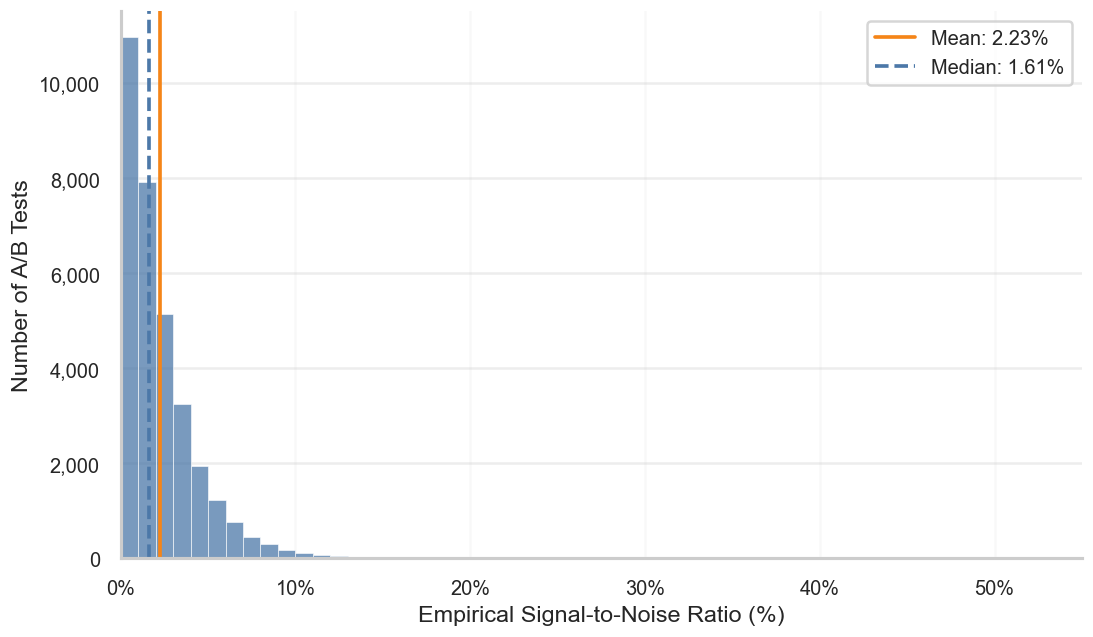

Figure note: SNR >= 10%: 305 tests (0.94%); SNR >= 20%: 6 tests (0.02%).

In [6]:
snr_distribution = per_test["empirical_snr"].dropna().copy()
snr_distribution_pct = pct(snr_distribution)
tail_10_count = int(snr_distribution_pct.ge(10).sum())
tail_20_count = int(snr_distribution_pct.ge(20).sum())
tail_10_share = tail_10_count / snr_distribution_pct.shape[0]
tail_20_share = tail_20_count / snr_distribution_pct.shape[0]
snr_summary = pd.DataFrame(
    [
        {"statistic": "Eligible tests", "value": f"{len(per_test):,}"},
        {"statistic": "Tests with defined SNR", "value": f"{snr_distribution.shape[0]:,}"},
        {"statistic": "Undefined SNR tests", "value": f"{per_test['empirical_snr'].isna().sum():,}"},
        {"statistic": "Mean SNR", "value": f"{snr_distribution_pct.mean():.2f}%"},
        {"statistic": "Median SNR", "value": f"{snr_distribution_pct.median():.2f}%"},
        {"statistic": "95th percentile", "value": f"{snr_distribution_pct.quantile(0.95):.2f}%"},
        {"statistic": "99th percentile", "value": f"{snr_distribution_pct.quantile(0.99):.2f}%"},
        {"statistic": "SNR >= 10%", "value": f"{tail_10_count:,} ({pct(tail_10_share):.2f}%)"},
        {"statistic": "SNR >= 20%", "value": f"{tail_20_count:,} ({pct(tail_20_share):.2f}%)"},
        {"statistic": "Maximum SNR", "value": f"{snr_distribution_pct.max():.2f}%"},
    ]
)
display(snr_summary)

fig, ax = plt.subplots(figsize=(9, 5.2), constrained_layout=True)
bin_max = np.ceil(snr_distribution_pct.max())
sns.histplot(
    snr_distribution_pct,
    bins=np.arange(0, bin_max + 1, 1),
    color="#4C78A8",
    edgecolor="white",
    linewidth=0.35,
    ax=ax,
)
mean_snr = snr_distribution_pct.mean()
median_snr = snr_distribution_pct.median()
ax.axvline(mean_snr, color="#F58518", linewidth=2.2, label=f"Mean: {mean_snr:.2f}%")
ax.axvline(median_snr, color="#4C78A8", linewidth=2.2, linestyle="--", label=f"Median: {median_snr:.2f}%")
# ax.set_title("Distribution Of Empirical SNR Across Upworthy Tests")
ax.set_xlabel("Empirical Signal-to-Noise Ratio (%)")
ax.set_ylabel("Number of A/B Tests")
ax.set_xlim(0, bin_max)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.grid(True, axis="y", alpha=0.35)
ax.grid(True, axis="x", alpha=0.12)
ax.legend(frameon=True)
sns.despine(ax=ax)
save_fig(fig, "snr_distribution")
plt.show()
display(Markdown(
    f"Figure note: SNR >= 10%: {tail_10_count:,} tests ({pct(tail_10_share):.2f}%); "
    f"SNR >= 20%: {tail_20_count:,} tests ({pct(tail_20_share):.2f}%)."
))

## Winner-Runner-Up Gap Distribution

This histogram reports the distribution of the raw observed CTR gap between the selected winner and the runner-up in each eligible test. This is the numerator of the empirical SNR calculation, expressed directly in percentage points.

,statistic,value
0,Eligible tests,"32,389"
1,Mean gap,0.302 pp
2,Standard deviation,0.358 pp
3,Minimum gap,0.000 pp
4,25th percentile,0.083 pp
5,Median gap,0.193 pp
6,75th percentile,0.394 pp
7,90th percentile,0.693 pp
8,95th percentile,0.945 pp
9,99th percentile,1.656 pp


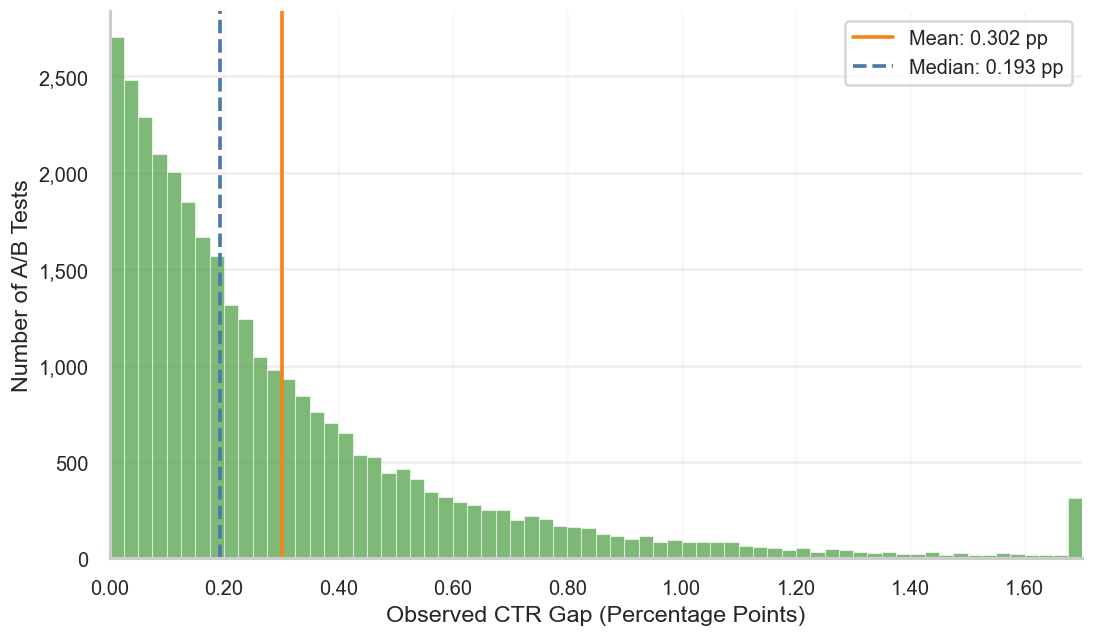

Figure note: Gap >= 1 pp: 1,418 tests (4.38%); gap >= 2 pp: 167 tests (0.52%). The rightmost bin includes the upper tail.

In [7]:
gap_distribution_pp = per_test["winner_runner_up_gap_pp"].dropna().copy()
tie_count = int(gap_distribution_pp.eq(0).sum())
close_010_count = int(gap_distribution_pp.lt(0.10).sum())
close_025_count = int(gap_distribution_pp.lt(0.25).sum())
tail_1pp_count = int(gap_distribution_pp.ge(1).sum())
tail_2pp_count = int(gap_distribution_pp.ge(2).sum())
tail_1pp_share = tail_1pp_count / gap_distribution_pp.shape[0]
tail_2pp_share = tail_2pp_count / gap_distribution_pp.shape[0]
mean_gap = gap_distribution_pp.mean()
p25_gap = gap_distribution_pp.quantile(0.25)
median_gap = gap_distribution_pp.median()
p75_gap = gap_distribution_pp.quantile(0.75)
p90_gap = gap_distribution_pp.quantile(0.90)
p95_gap = gap_distribution_pp.quantile(0.95)
p99_gap = gap_distribution_pp.quantile(0.99)
gap_summary = pd.DataFrame(
    [
        {"statistic": "Eligible tests", "value": f"{gap_distribution_pp.shape[0]:,}"},
        {"statistic": "Mean gap", "value": f"{gap_distribution_pp.mean():.3f} pp"},
        {"statistic": "Standard deviation", "value": f"{gap_distribution_pp.std():.3f} pp"},
        {"statistic": "Minimum gap", "value": f"{gap_distribution_pp.min():.3f} pp"},
        {"statistic": "25th percentile", "value": f"{p25_gap:.3f} pp"},
        {"statistic": "Median gap", "value": f"{median_gap:.3f} pp"},
        {"statistic": "75th percentile", "value": f"{p75_gap:.3f} pp"},
        {"statistic": "90th percentile", "value": f"{p90_gap:.3f} pp"},
        {"statistic": "95th percentile", "value": f"{p95_gap:.3f} pp"},
        {"statistic": "99th percentile", "value": f"{p99_gap:.3f} pp"},
        {"statistic": "Maximum gap", "value": f"{gap_distribution_pp.max():.3f} pp"},
        {"statistic": "Tied top observed CTR", "value": f"{tie_count:,} ({pct(tie_count / gap_distribution_pp.shape[0]):.2f}%)"},
        {"statistic": "Gap < 0.10 pp", "value": f"{close_010_count:,} ({pct(close_010_count / gap_distribution_pp.shape[0]):.2f}%)"},
        {"statistic": "Gap < 0.25 pp", "value": f"{close_025_count:,} ({pct(close_025_count / gap_distribution_pp.shape[0]):.2f}%)"},
        {"statistic": "Gap >= 1 pp", "value": f"{tail_1pp_count:,} ({pct(tail_1pp_share):.2f}%)"},
        {"statistic": "Gap >= 2 pp", "value": f"{tail_2pp_count:,} ({pct(tail_2pp_share):.2f}%)"},
    ]
)
display(gap_summary)

fig, ax = plt.subplots(figsize=(9, 5.2), constrained_layout=True)
plot_cap = np.ceil(p99_gap * 20) / 20
sns.histplot(
    gap_distribution_pp.clip(upper=plot_cap),
    bins=np.arange(0, plot_cap + 0.025, 0.025),
    color="#54A24B",
    edgecolor="white",
    linewidth=0.35,
    ax=ax,
)
ax.axvline(mean_gap, color="#F58518", linewidth=2.2, label=f"Mean: {mean_gap:.3f} pp")
ax.axvline(median_gap, color="#4C78A8", linewidth=2.2, linestyle="--", label=f"Median: {median_gap:.3f} pp")
# ax.set_title("Distribution Of Winner-Runner-Up CTR Gap Across Upworthy Tests")
ax.set_xlabel("Observed CTR Gap (Percentage Points)")
ax.set_ylabel("Number of A/B Tests")
ax.set_xlim(0, plot_cap)
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:.2f}"))
ax.grid(True, axis="y", alpha=0.35)
ax.grid(True, axis="x", alpha=0.12)
ax.legend(frameon=True)
sns.despine(ax=ax)
save_fig(fig, "winner_runner_up_gap_distribution")
plt.show()
display(Markdown(
    f"Figure note: Gap >= 1 pp: {tail_1pp_count:,} tests ({pct(tail_1pp_share):.2f}%); "
    f"gap >= 2 pp: {tail_2pp_count:,} tests ({pct(tail_2pp_share):.2f}%). "
    "The rightmost bin includes the upper tail."
))

## Headline Result

The table reports the selected winner's naive CTR, each corrected CTR, and the implied overstatement. Parentheses report cross-test standard errors in percentage points (pp).

There are two useful aggregation views:

- Test average: each test receives equal weight.
- Winner-impression weighted: selected winners with more impressions receive more weight.

The paper-facing headline table uses the test-average view because it describes the average winner-selection problem faced across clickability tests.


In [8]:
def mean_se(values: pd.Series) -> float:
    """Return the cross-test standard error of a mean."""
    clean = pd.to_numeric(values, errors="coerce").dropna()
    if clean.shape[0] <= 1:
        return np.nan
    return clean.std(ddof=1) / np.sqrt(clean.shape[0])


def ratio_of_means_and_se(
    numerator: pd.Series, denominator: pd.Series
) -> tuple[float, float]:
    """Return a ratio of paired means and its delta-method standard error."""
    paired = pd.concat([numerator, denominator], axis=1).dropna()
    numerator_values = paired.iloc[:, 0].to_numpy(dtype=float)
    denominator_values = paired.iloc[:, 1].to_numpy(dtype=float)
    denominator_mean = denominator_values.mean()
    ratio = numerator_values.mean() / denominator_mean
    residual = numerator_values - ratio * denominator_values
    se = residual.std(ddof=1) / (np.sqrt(paired.shape[0]) * denominator_mean)
    return ratio, se


headline = (
    summary_tables.loc[summary_tables["group"].eq("overall")]
    .assign(
        estimator_label=lambda df: df["estimator"].map(ESTIMATOR_LABELS),
        naive_ctr_pct=lambda df: pct(df["test_weighted_mean_naive_ctr"]),
        corrected_ctr_pct=lambda df: pct(df["test_weighted_mean_corrected_ctr"]),
        overstatement_pp=lambda df: pct(df["test_weighted_mean_bias"]),
        overstatement_pct_of_naive=lambda df: pct(df["test_weighted_mean_bias_pct_of_naive_ctr"]),
        winner_weighted_overstatement_pp=lambda df: pct(df["winner_impression_weighted_mean_bias"]),
        winner_weighted_naive_ctr_pct=lambda df: pct(df["winner_impression_weighted_mean_naive_ctr"]),
        aggregate_overstatement_pct=lambda df: pct(df["aggregate_bias_pct_of_weighted_naive_ctr"]),
    )
    [[
        "estimator",
        "estimator_label",
        "n_tests",
        "selected_impressions",
        "naive_ctr_pct",
        "corrected_ctr_pct",
        "overstatement_pp",
        "overstatement_pct_of_naive",
        "winner_weighted_naive_ctr_pct",
        "winner_weighted_overstatement_pp",
        "aggregate_overstatement_pct",
    ]]
)

headline["corrected_ctr_se_pp"] = [
    pct(mean_se(per_test[f"{estimator}_corrected_ctr"])) for estimator in headline["estimator"]
]
headline["overstatement_se_pp"] = [
    pct(mean_se(per_test[f"{estimator}_estimated_bias"])) for estimator in headline["estimator"]
]
naive_ratio_stats = {
    estimator: ratio_of_means_and_se(
        per_test[f"{estimator}_estimated_bias"],
        per_test["naive_selected_ctr"],
    )
    for estimator in headline["estimator"]
}
headline["overstatement_pct_of_naive"] = [
    pct(naive_ratio_stats[estimator][0]) for estimator in headline["estimator"]
]
headline["overstatement_pct_of_naive_se"] = [
    pct(naive_ratio_stats[estimator][1]) for estimator in headline["estimator"]
]

naive_ctr_mean_pct = pct(per_test["naive_selected_ctr"].mean())
naive_ctr_se_pp = pct(mean_se(per_test["naive_selected_ctr"]))

headline_paper_rows = [
    {
        "Estimator": "No Correction",
        "CTR estimate": f"{naive_ctr_mean_pct:.3f}% ({naive_ctr_se_pp:.3f}%)",
        "Estimated overstatement": "Reference",
        "Overstatement / naive CTR": "Reference",
    }
]
for row in headline.itertuples(index=False):
    headline_paper_rows.append(
        {
            "Estimator": row.estimator_label,
            "CTR estimate": f"{row.corrected_ctr_pct:.3f}% ({row.corrected_ctr_se_pp:.3f}%)",
            "Estimated overstatement": f"{row.overstatement_pp:.3f} pp ({row.overstatement_se_pp:.4f} pp)",
            "Overstatement / naive CTR": (
                f"{row.overstatement_pct_of_naive:.2f}% "
                f"({row.overstatement_pct_of_naive_se:.2f}%)"
            ),
        }
    )
headline_paper_table = pd.DataFrame(headline_paper_rows)

display(
    Markdown(
        "Parentheses report standard errors in the same units as the corresponding estimates. "
        "Overstatement / naive CTR divides mean estimated overstatement by mean no-correction "
        "CTR; its standard error uses the paired delta method."
    )
)
display(headline_paper_table.style.hide(axis="index"))

std = headline.loc[headline["estimator_label"].eq(ESTIMATOR_LABELS["standard_bootstrap"])].iloc[0]
moon = headline.loc[headline["estimator_label"].eq(ESTIMATOR_LABELS["moon_bootstrap"])].iloc[0]
display(
    Markdown(
        "**Draft empirical takeaway.** "
        f"Across {int(std['n_tests']):,} eligible Upworthy tests, the naive selected winner's CTR is "
        f"{std['naive_ctr_pct']:.2f}% (SE {naive_ctr_se_pp:.3f} pp). The standard bootstrap estimates "
        f"an average overstatement of {std['overstatement_pp']:.3f} percentage points "
        f"(SE {std['overstatement_se_pp']:.4f} pp), or {std['overstatement_pct_of_naive']:.1f}% "
        f"of the naive selected CTR. The $m$-out-of-$n$ Bootstrap estimates "
        f"{moon['overstatement_pp']:.3f} percentage points (SE {moon['overstatement_se_pp']:.4f} pp), "
        f"or {moon['overstatement_pct_of_naive']:.1f}%."
    )
)



Parentheses report standard errors in the same units as the corresponding estimates. Overstatement / naive CTR divides mean estimated overstatement by mean no-correction CTR; its standard error uses the paired delta method.

Estimator,CTR estimate,Estimated overstatement,Overstatement / naive CTR
No Correction,2.058% (0.008%),Reference,Reference
Standard Bootstrap,1.935% (0.008%),0.123 pp (0.0005 pp),5.99% (0.03%)
$m$-out-of-$n$ Bootstrap ($\gamma=0.6$),1.831% (0.007%),0.227 pp (0.0005 pp),11.03% (0.03%)
Sample Splitting,1.882% (0.008%),0.176 pp (0.0006 pp),8.56% (0.04%)
Empirical Bayes,1.910% (0.008%),0.147 pp (0.0004 pp),7.17% (0.02%)
Hybrid Selective Inference,1.857% (0.008%),0.202 pp (0.0015 pp),9.83% (0.08%)


**Draft empirical takeaway.** Across 32,389 eligible Upworthy tests, the naive selected winner's CTR is 2.06% (SE 0.008 pp). The standard bootstrap estimates an average overstatement of 0.123 percentage points (SE 0.0005 pp), or 6.0% of the naive selected CTR. The $m$-out-of-$n$ Bootstrap estimates 0.227 percentage points (SE 0.0005 pp), or 11.0%.

In [9]:
# Generate copy-ready LaTeX for the headline results table.
headline_latex_table = headline_paper_table.copy()


def stack_estimate_and_se(value: str) -> str:
    """Place an estimate and its parenthetical standard error on separate lines."""
    value = value.replace("%", r"\%")
    mean, separator, standard_error = value.partition(" (")
    if not separator:
        return value
    return (
        r"\begin{tabular}[c]{@{}c@{}}"
        f"{mean}\\\\ ({standard_error}\n"
        r"\end{tabular}"
    )


for column in headline_latex_table.columns[1:]:
    headline_latex_table[column] = headline_latex_table[column].map(stack_estimate_and_se)

headline_latex = headline_latex_table.to_latex(
    index=False,
    escape=False,
    column_format="lccc",
    caption=(
        "Winner's curse corrections in the Upworthy A/B tests. "
        "Parentheses report standard errors in the same units as the corresponding estimates. "
        "Overstatement relative to naive CTR is the ratio of mean estimated overstatement "
        "to mean no-correction CTR."
    ),
    label="tab:upworthy-headline-results",
    position="!htbp",
)
print(headline_latex)


\begin{table}[!htbp]
\caption{Winner's curse corrections in the Upworthy A/B tests. Parentheses report standard errors in the same units as the corresponding estimates. Overstatement relative to naive CTR is the ratio of mean estimated overstatement to mean no-correction CTR.}
\label{tab:upworthy-headline-results}
\begin{tabular}{lccc}
\toprule
Estimator & CTR estimate & Estimated overstatement & Overstatement / naive CTR \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}2.058\%\\ (0.008\%)
\end{tabular} & Reference & Reference \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}1.935\%\\ (0.008\%)
\end{tabular} & \begin{tabular}[c]{@{}c@{}}0.123 pp\\ (0.0005 pp)
\end{tabular} & \begin{tabular}[c]{@{}c@{}}5.99\%\\ (0.03\%)
\end{tabular} \\
$m$-out-of-$n$ Bootstrap ($\gamma=0.6$) & \begin{tabular}[c]{@{}c@{}}1.831\%\\ (0.007\%)
\end{tabular} & \begin{tabular}[c]{@{}c@{}}0.227 pp\\ (0.0005 pp)
\end{tabular} & \begin{tabular}[c]{@{}c@{}}11.03\%\\ (0.03\%)
\end{tabular} \\
Sample Split

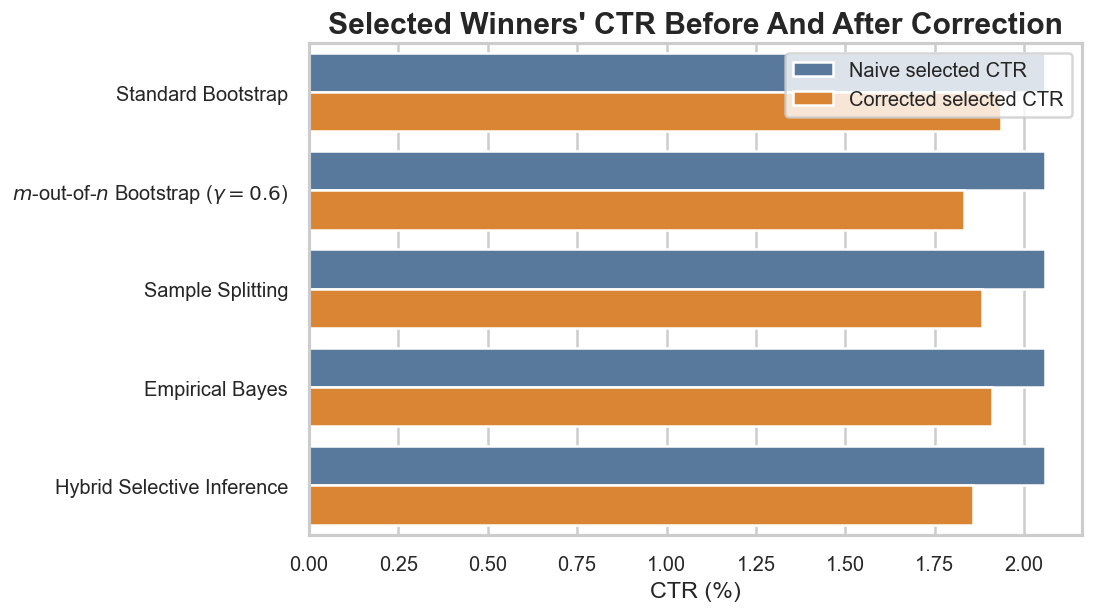

In [10]:
fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
plot_headline = headline.melt(
    id_vars="estimator_label",
    value_vars=["naive_ctr_pct", "corrected_ctr_pct"],
    var_name="series",
    value_name="ctr_pct",
)
plot_headline["series"] = plot_headline["series"].map(
    {"naive_ctr_pct": "Naive selected CTR", "corrected_ctr_pct": "Corrected selected CTR"}
)
sns.barplot(
    data=plot_headline,
    x="ctr_pct",
    y="estimator_label",
    hue="series",
    ax=ax,
    palette=["#4C78A8", "#F58518"],
)
ax.set_title("Selected Winners' CTR Before And After Correction")
ax.set_xlabel("CTR (%)")
ax.set_ylabel("")
ax.legend(title="")
save_fig(fig, "headline_naive_vs_corrected_ctr")
plt.show()

## Dataset Context Figures

These plots show the empirical setting: most tests have four to six arms, and many selected winners beat the runner-up by a small observed CTR gap.


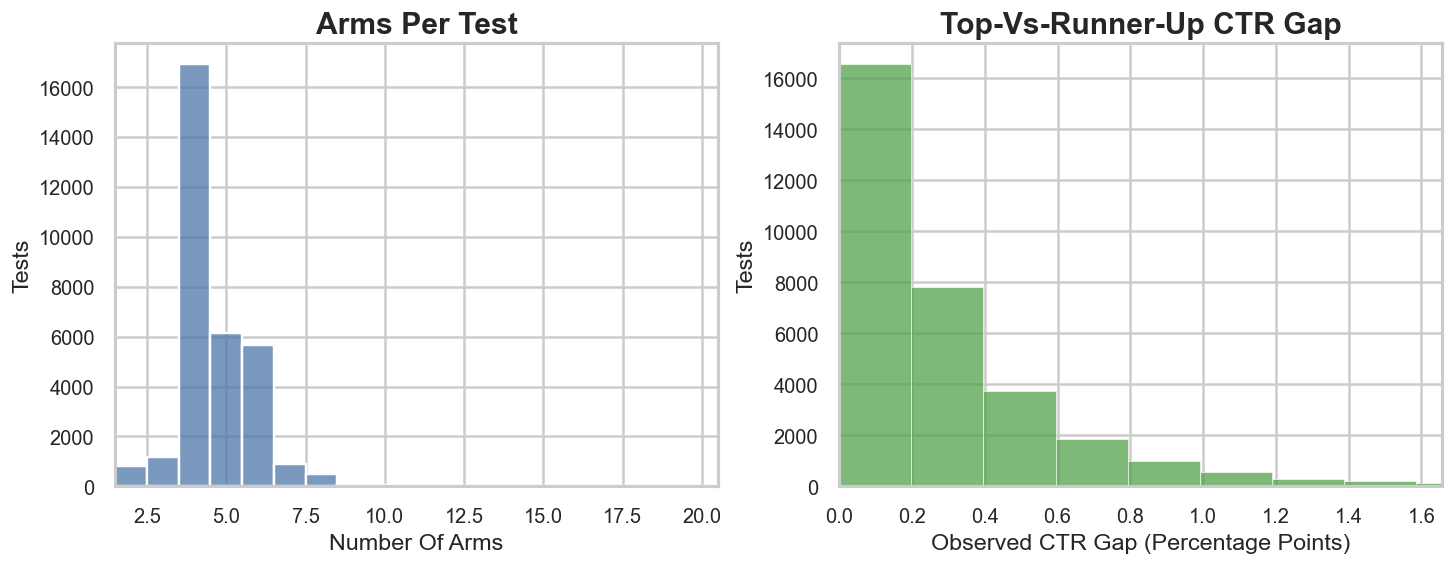

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)

sns.histplot(data=per_test, x="n_arms", binwidth=1, discrete=True, color="#4C78A8", ax=axes[0])
axes[0].set_title("Arms Per Test")
axes[0].set_xlabel("Number Of Arms")
axes[0].set_ylabel("Tests")
axes[0].set_xlim(1.5, min(20.5, per_test["n_arms"].max() + 0.5))

sns.histplot(
    data=per_test,
    x="winner_runner_up_gap_pp",
    bins=80,
    color="#54A24B",
    ax=axes[1],
)
axes[1].set_title("Top-Vs-Runner-Up CTR Gap")
axes[1].set_xlabel("Observed CTR Gap (Percentage Points)")
axes[1].set_ylabel("Tests")
axes[1].set_xlim(0, per_test["winner_runner_up_gap_pp"].quantile(0.99))

save_fig(fig, "dataset_context")
plt.show()


## Distribution Of Estimated Winner's Curse

Each observation is one Upworthy test. Bias is `naive selected CTR - corrected selected CTR`, shown in percentage points. The distribution is right-skewed because near-tie tests and low-impression selected winners receive larger corrections.

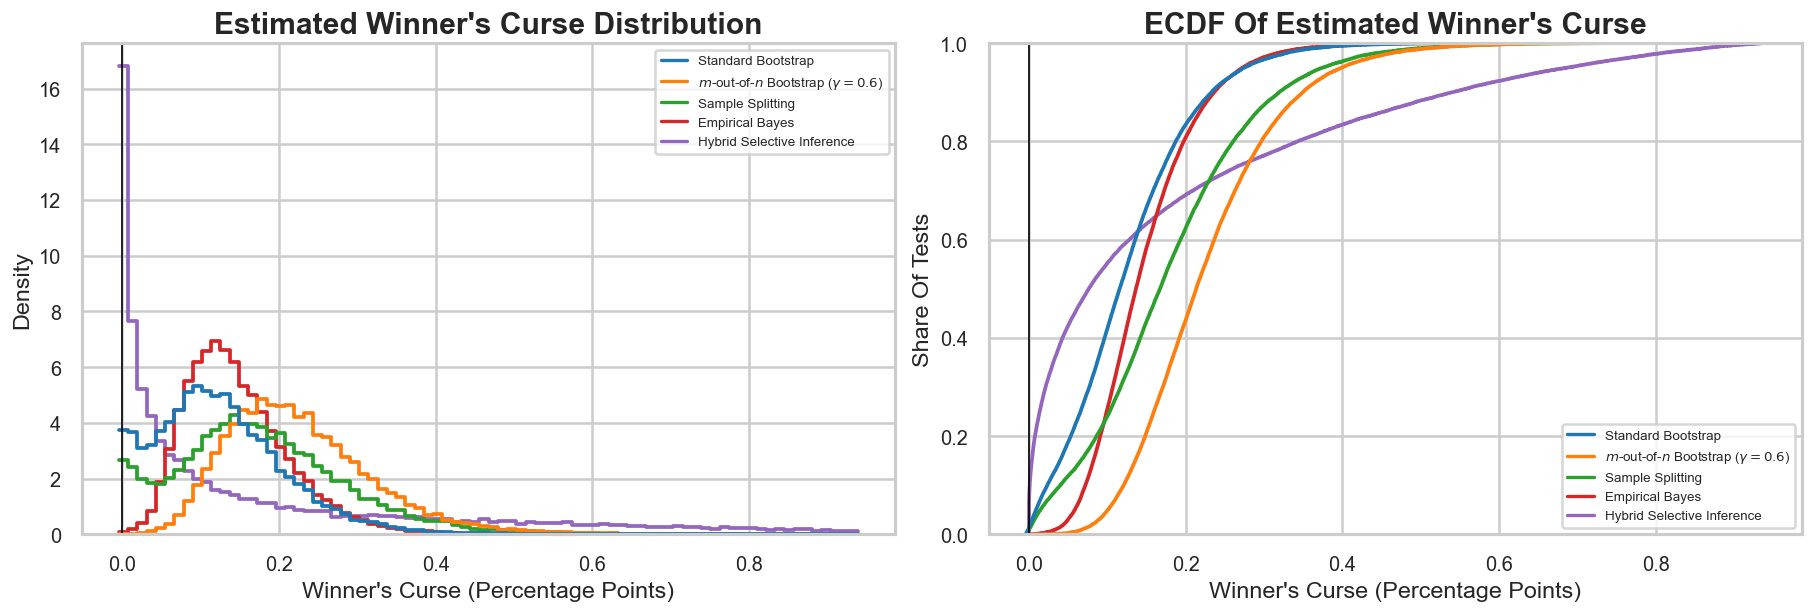

In [12]:
plot_dist = estimator_long.dropna(subset=["bias_pp"]).copy()
xmax = plot_dist["bias_pp"].quantile(0.995)
xmin = plot_dist["bias_pp"].quantile(0.005)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
dist_hue_order = [ESTIMATOR_LABELS[e] for e in available_estimators]
dist_palette = dict(zip(dist_hue_order, sns.color_palette("tab10", n_colors=len(dist_hue_order))))

sns.histplot(
    data=plot_dist.loc[plot_dist["bias_pp"].between(xmin, xmax)],
    x="bias_pp",
    hue="estimator_label",
    hue_order=dist_hue_order,
    palette=dist_palette,
    bins=80,
    stat="density",
    element="step",
    fill=False,
    common_norm=False,
    ax=axes[0],
)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Estimated Winner's Curse Distribution")
axes[0].set_xlabel("Winner's Curse (Percentage Points)")
axes[0].set_ylabel("Density")

sns.ecdfplot(
    data=plot_dist.loc[plot_dist["bias_pp"].between(xmin, xmax)],
    x="bias_pp",
    hue="estimator_label",
    hue_order=dist_hue_order,
    palette=dist_palette,
    ax=axes[1],
)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("ECDF Of Estimated Winner's Curse")
axes[1].set_xlabel("Winner's Curse (Percentage Points)")
axes[1].set_ylabel("Share Of Tests")

for ax in axes:
    handles = [plt.Line2D([0], [0], color=dist_palette[label], lw=2, label=label) for label in dist_hue_order]
    ax.legend(handles=handles, fontsize=8)

save_fig(fig, "winner_curse_distribution")
plt.show()

In [13]:
distribution_table = (
    estimator_long.dropna(subset=["bias_pp", "bias_pct_of_naive"])
    .groupby("estimator_label", sort=False)
    .agg(
        tests=("clickability_test_id", "nunique"),
        mean_bias_pp=("bias_pp", "mean"),
        median_bias_pp=("bias_pp", "median"),
        p25_bias_pp=("bias_pp", lambda s: s.quantile(0.25)),
        p75_bias_pp=("bias_pp", lambda s: s.quantile(0.75)),
        mean_pct_naive=("bias_pct_of_naive", "mean"),
        median_pct_naive=("bias_pct_of_naive", "median"),
        negative_share=("bias_pp", lambda s: s.lt(0).mean() * 100),
    )
    .reset_index()
)

display(
    distribution_table.style.format(
        {
            "tests": "{:,}",
            "mean_bias_pp": "{:.3f}",
            "median_bias_pp": "{:.3f}",
            "p25_bias_pp": "{:.3f}",
            "p75_bias_pp": "{:.3f}",
            "mean_pct_naive": "{:.1f}%",
            "median_pct_naive": "{:.1f}%",
            "negative_share": "{:.1f}%",
        }
    ).hide(axis="index")
)

estimator_label,tests,mean_bias_pp,median_bias_pp,p25_bias_pp,p75_bias_pp,mean_pct_naive,median_pct_naive,negative_share
Standard Bootstrap,"32,389",0.123,0.114,0.063,0.172,7.8%,7.1%,2.7%
$m$-out-of-$n$ Bootstrap ($\gamma=0.6$),"32,389",0.227,0.213,0.159,0.279,13.4%,12.6%,0.0%
Sample Splitting,"32,389",0.176,0.166,0.100,0.239,11.0%,10.3%,2.1%
Empirical Bayes,"32,389",0.147,0.137,0.099,0.184,8.8%,8.1%,0.0%
Hybrid Selective Inference,"32,254",0.202,0.082,0.015,0.297,13.2%,5.2%,0.0%


## Mechanism 1: Low SNR

The paper's simulations emphasize that winner's curse is largest when signal is small relative to outcome noise. In the empirical data, the same pattern appears across real tests: when the leading arms are close relative to their pooled within-arm click standard deviation, the correction is larger.

For the binned line chart, each point is the average estimated winner's curse within an empirical SNR decile: `0-10%`, `10-20%`, ..., `90-100%` of tests sorted by SNR. The error bar is a 95% confidence interval for that bin mean: `average +/- 1.96 * sd / sqrt(n)`, where `sd` is the cross-test standard deviation of the estimated winner's curse inside the bin. These intervals describe uncertainty in the average correction for the bin, not the dispersion of individual tests.

The SNR ratio is unitless; the figures below display `100 * empirical_snr` so the x-axis follows the paper-style percentage scale.


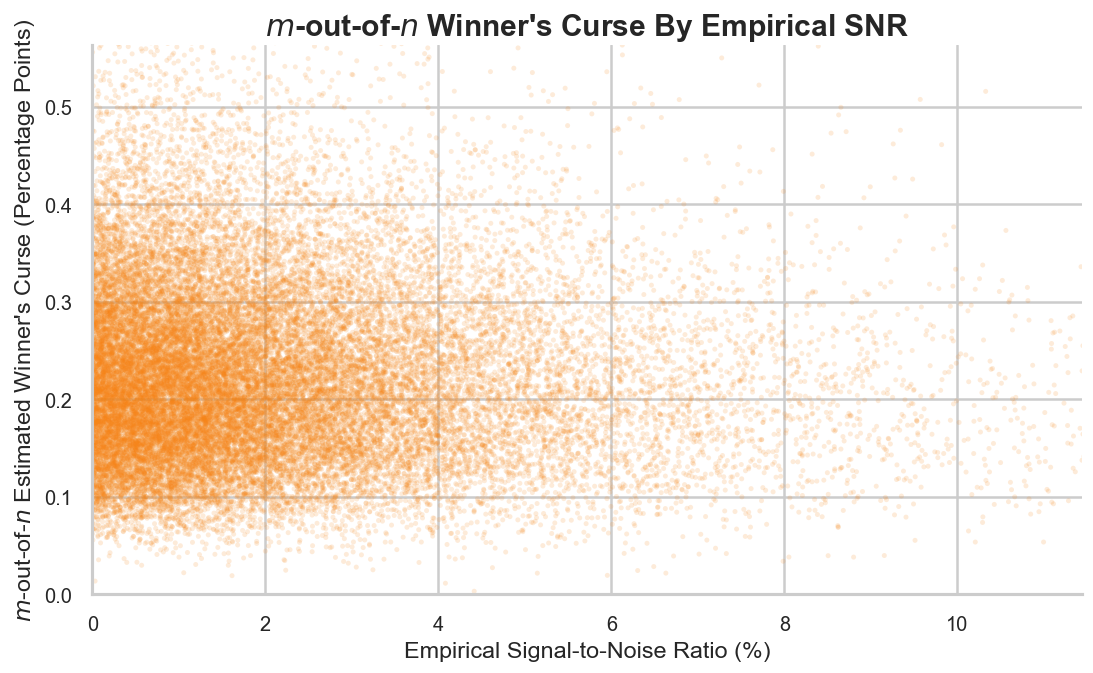

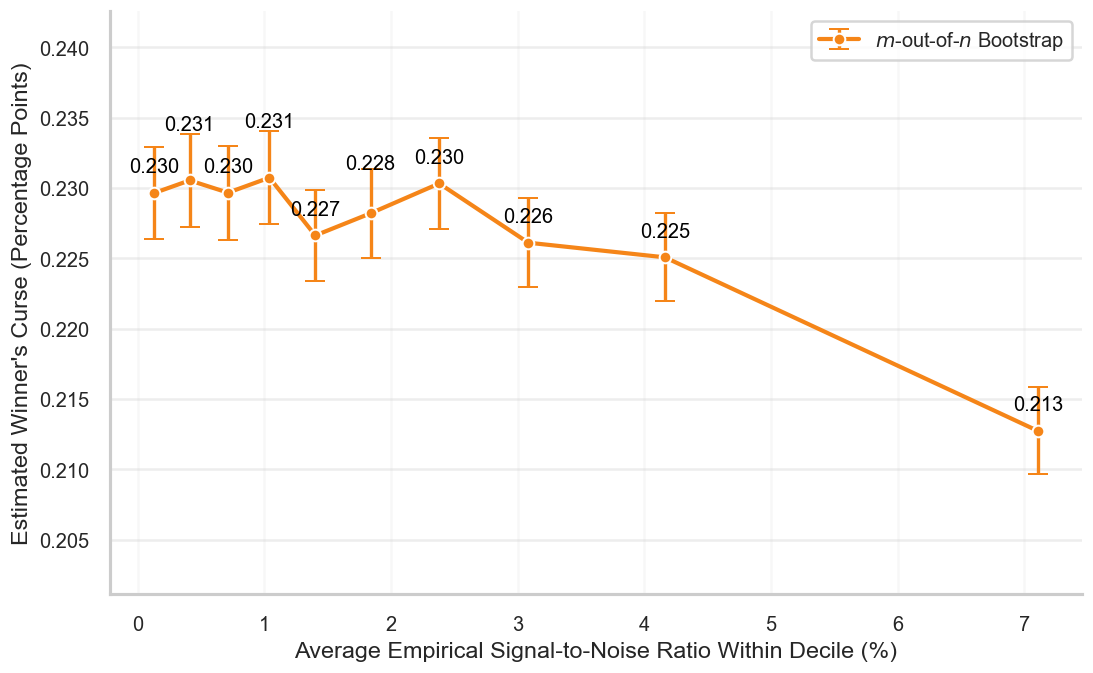

estimator_label,snr_decile,n,snr_average_pct,average_observed_gap_pp,winner_curse_pct_of_observed_gap,mean,se,ci_half_width,ci_low,ci_high
$m$-out-of-$n$ Bootstrap,0-10%,"3,239.0",0.1%,0.016,1427.3%,0.230,0.0017,0.0033,0.226,0.233
$m$-out-of-$n$ Bootstrap,10-20%,"3,239.0",0.4%,0.052,445.7%,0.231,0.0017,0.0033,0.227,0.234
$m$-out-of-$n$ Bootstrap,20-30%,"3,239.0",0.7%,0.090,254.3%,0.230,0.0017,0.0033,0.226,0.233
$m$-out-of-$n$ Bootstrap,30-40%,"3,239.0",1.0%,0.132,174.3%,0.231,0.0017,0.0033,0.227,0.234
$m$-out-of-$n$ Bootstrap,40-50%,"3,239.0",1.4%,0.177,128.0%,0.227,0.0016,0.0032,0.223,0.230
$m$-out-of-$n$ Bootstrap,50-60%,"3,238.0",1.8%,0.235,97.0%,0.228,0.0016,0.0032,0.225,0.231
$m$-out-of-$n$ Bootstrap,60-70%,"3,239.0",2.4%,0.310,74.4%,0.230,0.0017,0.0032,0.227,0.234
$m$-out-of-$n$ Bootstrap,70-80%,"3,239.0",3.1%,0.399,56.6%,0.226,0.0016,0.0032,0.223,0.229
$m$-out-of-$n$ Bootstrap,80-90%,"3,239.0",4.2%,0.562,40.1%,0.225,0.0016,0.0031,0.222,0.228
$m$-out-of-$n$ Bootstrap,90-100%,"3,239.0",7.1%,1.042,20.4%,0.213,0.0016,0.0031,0.210,0.216


In [14]:
def mean_ci(group: pd.DataFrame, value_col: str) -> pd.Series:
    values = group[value_col].dropna()
    n = values.shape[0]
    mean = values.mean()
    sd = values.std(ddof=1) if n > 1 else np.nan
    se = sd / np.sqrt(n) if n > 1 else np.nan
    ci_half_width = 1.96 * se if n > 1 else np.nan
    return pd.Series(
        {
            "n": n,
            "mean": mean,
            "sd": sd,
            "se": se,
            "ci_half_width": ci_half_width,
            "ci_low": mean - ci_half_width,
            "ci_high": mean + ci_half_width,
        }
    )

per_test["empirical_snr_pct"] = pct(per_test["empirical_snr"])
estimator_long["empirical_snr_pct"] = pct(estimator_long["empirical_snr"])

moon_scatter = per_test.dropna(
    subset=["empirical_snr_pct", "moon_bootstrap_bias_pp"]
).copy()
scatter_x_cap = moon_scatter["empirical_snr_pct"].quantile(0.995)
scatter_y_cap = moon_scatter["moon_bootstrap_bias_pp"].quantile(0.995)

fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)
ax.scatter(
    moon_scatter["empirical_snr_pct"],
    moon_scatter["moon_bootstrap_bias_pp"],
    s=9,
    alpha=0.16,
    color="#F58518",
    edgecolors="none",
    rasterized=True,
)
ax.axhline(0, color="black", linewidth=1, alpha=0.7)
ax.set_xlim(0, scatter_x_cap)
ax.set_ylim(0, scatter_y_cap)
ax.set_title("$m$-out-of-$n$ Winner's Curse By Empirical SNR")
ax.set_xlabel("Empirical Signal-to-Noise Ratio (%)")
ax.set_ylabel("$m$-out-of-$n$ Estimated Winner's Curse (Percentage Points)")
sns.despine(ax=ax)
save_fig(fig, "moon_bias_scatter_by_snr")
plt.show()

snr_plot_data = estimator_long.loc[
    estimator_long["estimator"].eq("moon_bootstrap") & estimator_long["empirical_snr"].notna()
].copy()
snr_plot_data["estimator_label"] = MOON_PLOT_LABEL
snr_summary = (
    snr_plot_data.groupby(["estimator_label", "snr_decile"], observed=True)
    .apply(lambda g: mean_ci(g, "bias_pp"), include_groups=False)
    .reset_index()
)
snr_mid = (
    per_test.dropna(subset=["snr_decile"])
    .groupby("snr_decile", observed=True)["empirical_snr"]
    .mean()
    .rename("snr_average")
    .reset_index()
)
snr_summary = snr_summary.merge(snr_mid, on="snr_decile", how="left")
snr_summary["snr_average_pct"] = pct(snr_summary["snr_average"])
snr_gap_summary = (
    per_test.dropna(subset=["snr_decile"])
    .groupby("snr_decile", observed=True)["winner_runner_up_gap_pp"]
    .mean()
    .rename("average_observed_gap_pp")
    .reset_index()
)
snr_summary = snr_summary.merge(snr_gap_summary, on="snr_decile", how="left")
snr_summary["winner_curse_pct_of_observed_gap"] = pct(
    snr_summary["mean"] / snr_summary["average_observed_gap_pp"]
)

fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)
line_palette = {MOON_PLOT_LABEL: "#F58518"}
snr_label_offsets = [(0, 10), (0, 28), (0, 10), (0, 28), (0, 10), (0, 24), (0, 10), (0, 10), (0, 10), (0, 10)]
for label, group in snr_summary.groupby("estimator_label", sort=False):
    ordered = group.sort_values("snr_average_pct")
    color = line_palette.get(label)
    yerr = np.vstack([
        ordered["mean"].to_numpy(dtype=float) - ordered["ci_low"].to_numpy(dtype=float),
        ordered["ci_high"].to_numpy(dtype=float) - ordered["mean"].to_numpy(dtype=float),
    ])
    ax.errorbar(
        ordered["snr_average_pct"],
        ordered["mean"],
        yerr=yerr,
        marker="o",
        markersize=7,
        markeredgecolor="white",
        markeredgewidth=1.2,
        linewidth=2.5,
        linestyle=PRIMARY_LINESTYLES.get(label, "-"),
        elinewidth=2.0,
        capsize=6,
        capthick=2.0,
        color=color,
        label=label,
    )
    for point_index, (x_value, y_value) in enumerate(
        zip(ordered["snr_average_pct"], ordered["mean"])
    ):
        ax.annotate(
            f"{y_value:.3f}",
            xy=(x_value, y_value),
            xytext=snr_label_offsets[point_index],
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=ANNOTATION_FONT_SIZE,
            color="black",
        )
ax.set_xlabel("Average Empirical Signal-to-Noise Ratio Within Decile (%)")
ax.set_ylabel("Estimated Winner's Curse (Percentage Points)")
snr_y_min = snr_summary["ci_low"].min()
snr_y_max = snr_summary["ci_high"].max()
snr_y_padding = max(0.002, 0.35 * (snr_y_max - snr_y_min))
ax.set_ylim(max(0, snr_y_min - snr_y_padding), snr_y_max + snr_y_padding)
ax.grid(True, axis="y", alpha=0.35)
ax.grid(True, axis="x", alpha=0.15)
ax.legend(frameon=True)
sns.despine(ax=ax)
save_fig(fig, "bias_by_snr")
plt.show()

display(
    snr_summary[["estimator_label", "snr_decile", "n", "snr_average_pct", "average_observed_gap_pp", "winner_curse_pct_of_observed_gap", "mean", "se", "ci_half_width", "ci_low", "ci_high"]]
    .style.format(
        {
            "n": "{:,}",
            "snr_average_pct": "{:.1f}%",
            "average_observed_gap_pp": "{:.3f}",
            "winner_curse_pct_of_observed_gap": "{:.1f}%",
            "mean": "{:.3f}",
            "se": "{:.4f}",
            "ci_half_width": "{:.4f}",
            "ci_low": "{:.3f}",
            "ci_high": "{:.3f}",
        }
    )
    .hide(axis="index")
)


## Mechanism 2: More Arms Increase Selection Over Noise

The selected winner is the maximum over the candidate arms. Holding the general environment fixed, more arms create more chances for at least one arm to receive a favorable noise draw.

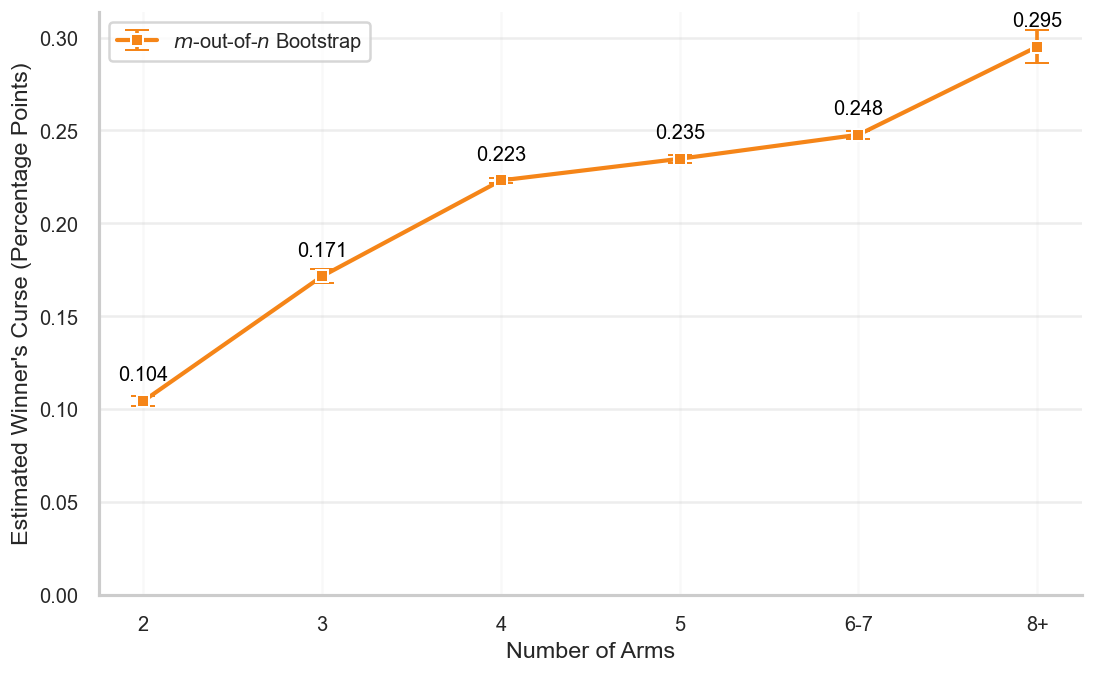

estimator_label,arm_count_bin,n,average_observed_gap_pp,winner_curse_pct_of_observed_gap,mean,se,ci_half_width,ci_low,ci_high
$m$-out-of-$n$ Bootstrap,2,837.0,0.360,28.9%,0.104,0.0015,0.0029,0.101,0.107
$m$-out-of-$n$ Bootstrap,3,"1,166.0",0.337,50.9%,0.171,0.0020,0.0038,0.168,0.175
$m$-out-of-$n$ Bootstrap,4,"16,918.0",0.338,66.0%,0.223,0.0007,0.0013,0.222,0.224
$m$-out-of-$n$ Bootstrap,5,"6,156.0",0.261,89.7%,0.235,0.0012,0.0023,0.232,0.237
$m$-out-of-$n$ Bootstrap,6-7,"6,563.0",0.241,102.6%,0.248,0.0012,0.0023,0.245,0.250
$m$-out-of-$n$ Bootstrap,8+,749.0,0.217,136.3%,0.295,0.0045,0.0088,0.286,0.304


In [15]:
arm_summary = (
    estimator_long.loc[estimator_long["estimator"].eq("moon_bootstrap")]
    .assign(estimator_label=MOON_PLOT_LABEL)
    .dropna(subset=["arm_count_bin", "bias_pp"])
    .groupby(["estimator_label", "arm_count_bin"], observed=True)
    .apply(lambda g: mean_ci(g, "bias_pp"), include_groups=False)
    .reset_index()
)
arm_summary["arm_count_bin"] = pd.Categorical(arm_summary["arm_count_bin"], categories=ARM_BIN_ORDER, ordered=True)
arm_summary = arm_summary.sort_values(["estimator_label", "arm_count_bin"])
arm_gap_summary = (
    per_test.dropna(subset=["arm_count_bin"])
    .groupby("arm_count_bin", observed=True)["winner_runner_up_gap_pp"]
    .mean()
    .rename("average_observed_gap_pp")
    .reset_index()
)
arm_summary = arm_summary.merge(arm_gap_summary, on="arm_count_bin", how="left")
arm_summary["winner_curse_pct_of_observed_gap"] = pct(
    arm_summary["mean"] / arm_summary["average_observed_gap_pp"]
)

fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)
x_positions = np.arange(len(ARM_BIN_ORDER), dtype=float)
arm_palette = {MOON_PLOT_LABEL: "#F58518"}
arm_markers = {MOON_PLOT_LABEL: "s"}
for label, group in arm_summary.groupby("estimator_label", sort=False):
    ordered = group.set_index("arm_count_bin").reindex(ARM_BIN_ORDER)
    x = x_positions
    y = ordered["mean"].to_numpy(dtype=float)
    yerr = np.vstack([
        y - ordered["ci_low"].to_numpy(dtype=float),
        ordered["ci_high"].to_numpy(dtype=float) - y,
    ])
    ax.errorbar(
        x,
        y,
        yerr=yerr,
        marker=arm_markers.get(label, "o"),
        markersize=7,
        markeredgecolor="white",
        markeredgewidth=1.2,
        linewidth=2.5,
        linestyle=PRIMARY_LINESTYLES.get(label, "-"),
        elinewidth=2.2,
        capsize=7,
        capthick=2.2,
        color=arm_palette.get(label),
        label=label,
    )
    for x_value, y_value in zip(x, y):
        ax.annotate(
            f"{y_value:.3f}",
            xy=(x_value, y_value),
            xytext=(0, 10),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=ANNOTATION_FONT_SIZE,
            color="black",
        )
ax.set_xticks(x_positions)
ax.set_xticklabels(ARM_BIN_ORDER)
ax.set_xlabel("Number of Arms")
ax.set_ylabel("Estimated Winner's Curse (Percentage Points)")
ax.set_ylim(bottom=0)
ax.grid(True, axis="y", alpha=0.35)
ax.grid(True, axis="x", alpha=0.12)
ax.legend(frameon=True)
sns.despine(ax=ax)
save_fig(fig, "bias_by_arm_count")
plt.show()

display(
    arm_summary[["estimator_label", "arm_count_bin", "n", "average_observed_gap_pp", "winner_curse_pct_of_observed_gap", "mean", "se", "ci_half_width", "ci_low", "ci_high"]]
    .style.format(
        {
            "n": "{:,}",
            "average_observed_gap_pp": "{:.3f}",
            "winner_curse_pct_of_observed_gap": "{:.1f}%",
            "mean": "{:.3f}",
            "se": "{:.4f}",
            "ci_half_width": "{:.4f}",
            "ci_low": "{:.3f}",
            "ci_high": "{:.3f}",
        }
    )
    .hide(axis="index")
)


## Mechanism 3: SNR And Arm Count Together

This heatmap combines the two main empirical mechanisms using SNR deciles. The highest corrections occur when tests have many candidate arms and the top observed arms are close relative to their pooled within-arm click standard deviation.


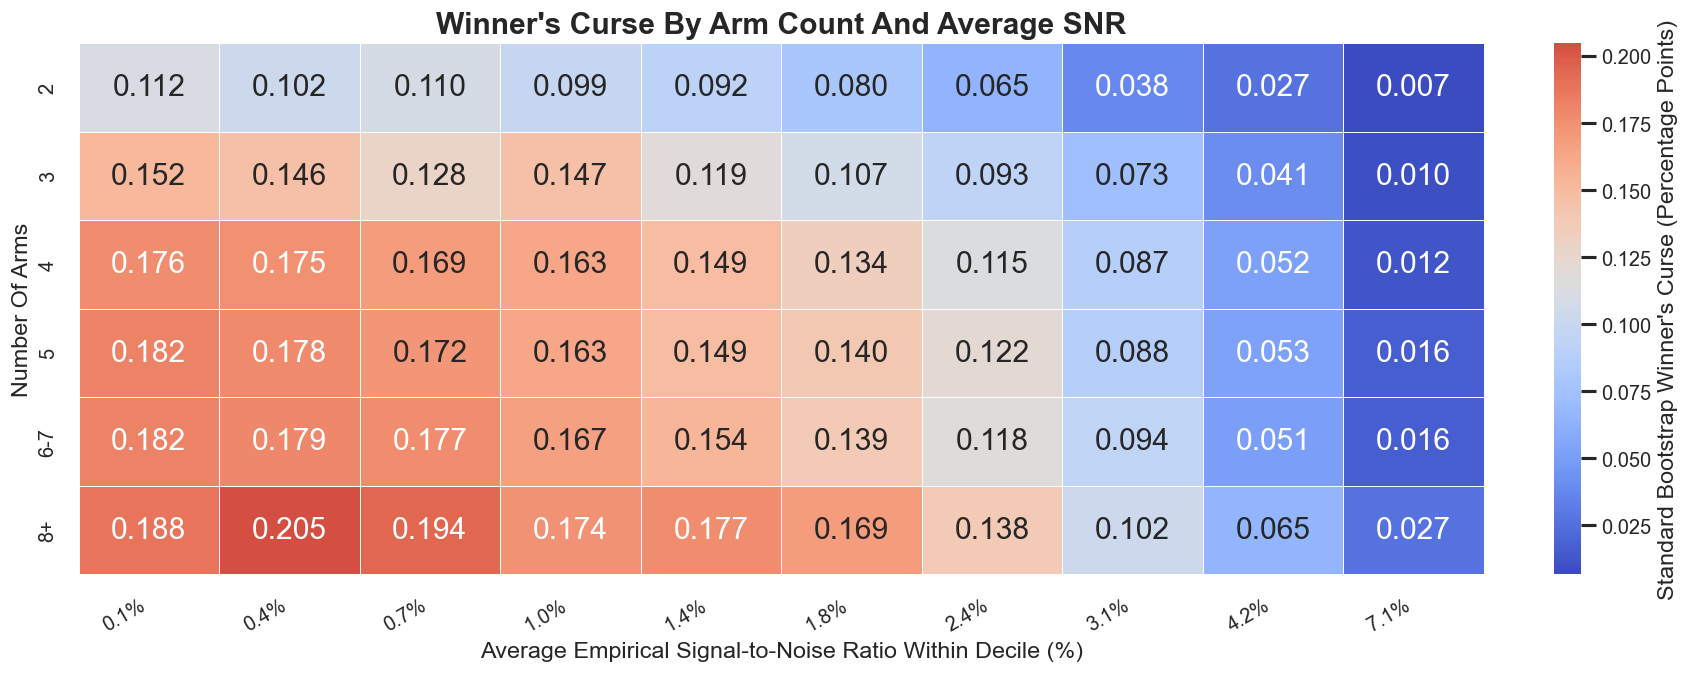

In [16]:
heat_data = per_test.dropna(subset=["snr_decile", "arm_count_bin", "standard_bootstrap_bias_pp"]).copy()
heat = heat_data.pivot_table(
    index="arm_count_bin",
    columns="snr_decile",
    values="standard_bootstrap_bias_pp",
    aggfunc="mean",
    observed=True,
)
heat = heat.reindex(index=ARM_BIN_ORDER, columns=SNR_DECILE_LABELS)
heat_snr_pct = (
    pct(heat_data.groupby("snr_decile", observed=True)["empirical_snr"].mean())
    .reindex(SNR_DECILE_LABELS)
)
heat_x_labels = [f"{value:.1f}%" if pd.notna(value) else "" for value in heat_snr_pct.to_numpy()]

fig, ax = plt.subplots(figsize=(14, 5.5), constrained_layout=True)
sns.heatmap(
    heat,
    cmap="coolwarm",
    center=float(heat.stack().mean()),
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    cbar_kws={"label": "Standard Bootstrap Winner's Curse (Percentage Points)"},
    ax=ax,
)
ax.set_title("Winner's Curse By Arm Count And Average SNR")
ax.set_xlabel("Average Empirical Signal-to-Noise Ratio Within Decile (%)")
ax.set_ylabel("Number Of Arms")
ax.set_xticklabels(heat_x_labels, rotation=30, ha="right")
save_fig(fig, "heatmap_bias_snr_arm_count")
plt.show()


## Mechanism 4: Sample Size And Total Test Impressions

More total test impressions reduce sampling noise. The plots below mirror Mechanism 1: a raw test-level scatter followed by decile means, using total test impressions only.


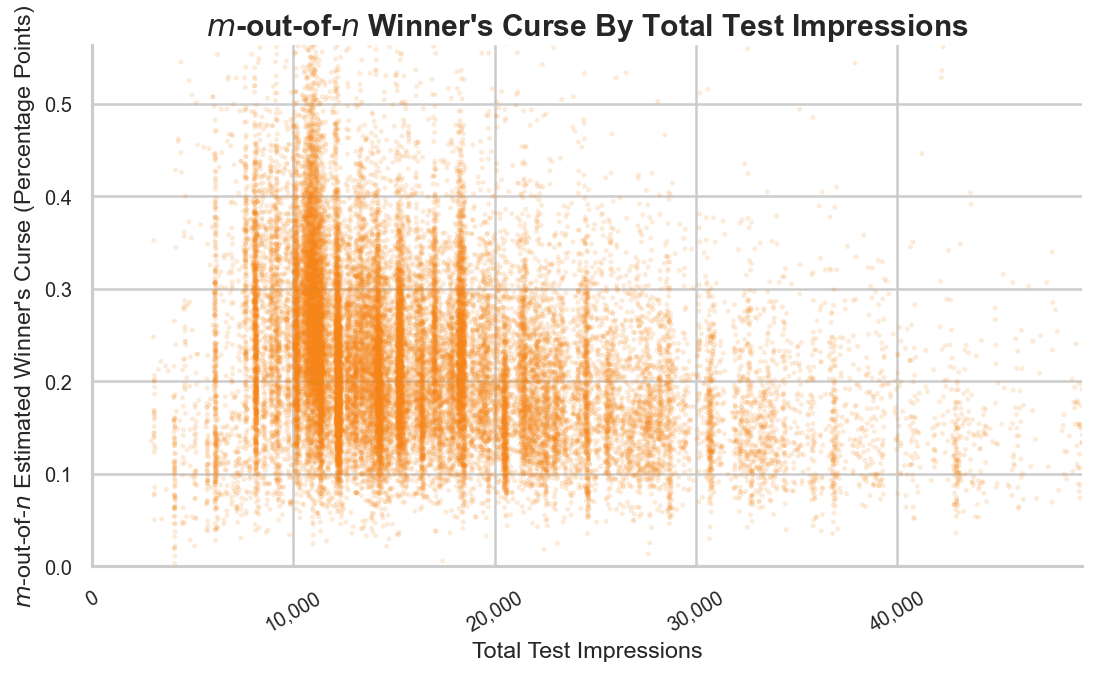

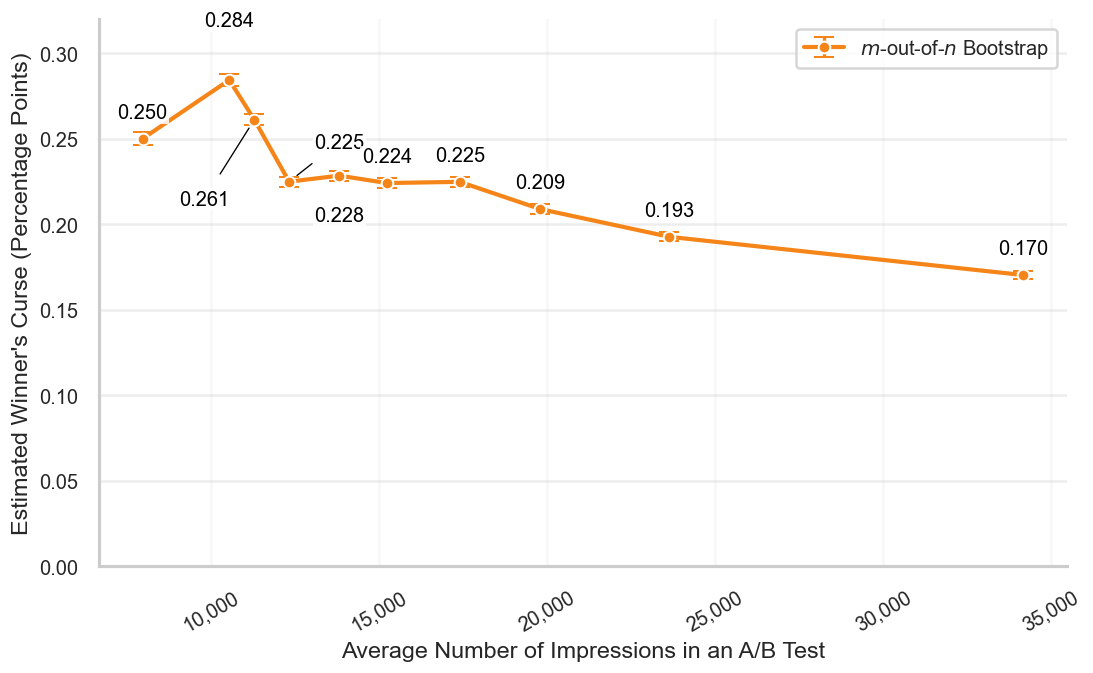

estimator_label,impression_decile_label,n,total_impressions_mean,average_observed_gap_pp,winner_curse_pct_of_observed_gap,mean,se,ci_half_width,ci_low,ci_high
$m$-out-of-$n$ Bootstrap,0-10%,"3,240.0","7,954",0.372,67.2%,0.250,0.0020,0.0039,0.246,0.254
$m$-out-of-$n$ Bootstrap,10-20%,"3,241.0","10,534",0.400,71.1%,0.284,0.0017,0.0034,0.281,0.288
$m$-out-of-$n$ Bootstrap,20-30%,"3,238.0","11,281",0.404,64.6%,0.261,0.0017,0.0033,0.258,0.264
$m$-out-of-$n$ Bootstrap,30-40%,"3,237.0","12,317",0.293,76.8%,0.225,0.0015,0.0030,0.222,0.228
$m$-out-of-$n$ Bootstrap,40-50%,"3,239.0","13,811",0.319,71.5%,0.228,0.0015,0.0029,0.226,0.231
$m$-out-of-$n$ Bootstrap,50-60%,"3,240.0","15,230",0.274,81.8%,0.224,0.0015,0.0029,0.221,0.227
$m$-out-of-$n$ Bootstrap,60-70%,"3,241.0","17,398",0.258,87.1%,0.225,0.0014,0.0028,0.222,0.228
$m$-out-of-$n$ Bootstrap,70-80%,"3,237.0","19,789",0.248,84.4%,0.209,0.0014,0.0028,0.206,0.212
$m$-out-of-$n$ Bootstrap,80-90%,"3,237.0","23,641",0.238,80.8%,0.193,0.0013,0.0026,0.190,0.195
$m$-out-of-$n$ Bootstrap,90-100%,"3,239.0","34,180",0.209,81.5%,0.170,0.0013,0.0026,0.168,0.173


In [17]:
per_test["total_impression_decile"] = pd.qcut(
    per_test["total_impressions"],
    q=10,
    duplicates="drop",
)

impression_scatter = per_test.dropna(
    subset=["total_impressions", "moon_bootstrap_bias_pp"]
).copy()
impression_scatter_x_cap = impression_scatter["total_impressions"].quantile(0.995)
impression_scatter_y_cap = impression_scatter["moon_bootstrap_bias_pp"].quantile(0.995)

fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)
ax.scatter(
    impression_scatter["total_impressions"],
    impression_scatter["moon_bootstrap_bias_pp"],
    s=9,
    alpha=0.16,
    color="#F58518",
    edgecolors="none",
    rasterized=True,
)
ax.axhline(0, color="black", linewidth=1, alpha=0.7)
ax.set_xlim(0, impression_scatter_x_cap)
ax.set_ylim(0, impression_scatter_y_cap)
ax.set_title("$m$-out-of-$n$ Winner's Curse By Total Test Impressions")
ax.set_xlabel("Total Test Impressions")
ax.set_ylabel("$m$-out-of-$n$ Estimated Winner's Curse (Percentage Points)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.tick_params(axis="x", rotation=30)
sns.despine(ax=ax)
save_fig(fig, "moon_bias_scatter_by_total_impressions")
plt.show()

impression_plot_data = (
    estimator_long.loc[estimator_long["estimator"].eq("moon_bootstrap")]
    .assign(estimator_label=MOON_PLOT_LABEL)
    .merge(
        per_test[["clickability_test_id", "total_impression_decile"]],
        on="clickability_test_id",
        how="left",
        validate="many_to_one",
    )
    .dropna(subset=["total_impression_decile", "bias_pp"])
)
impression_summary = (
    impression_plot_data.groupby(["estimator_label", "total_impression_decile"], observed=True)
    .apply(lambda g: mean_ci(g, "bias_pp"), include_groups=False)
    .reset_index()
)
impression_mid = (
    per_test.dropna(subset=["total_impression_decile"])
    .groupby("total_impression_decile", observed=True)
    .agg(total_impressions_mean=("total_impressions", "mean"))
    .reset_index()
    .sort_values("total_impressions_mean")
)
impression_mid["impression_decile_label"] = [
    f"{i * 10}-{(i + 1) * 10}%" for i in range(len(impression_mid))
]
impression_summary = impression_summary.merge(
    impression_mid,
    on="total_impression_decile",
    how="left",
)
impression_gap_summary = (
    per_test.dropna(subset=["total_impression_decile"])
    .groupby("total_impression_decile", observed=True)["winner_runner_up_gap_pp"]
    .mean()
    .rename("average_observed_gap_pp")
    .reset_index()
)
impression_summary = impression_summary.merge(
    impression_gap_summary,
    on="total_impression_decile",
    how="left",
)
impression_summary["winner_curse_pct_of_observed_gap"] = pct(
    impression_summary["mean"] / impression_summary["average_observed_gap_pp"]
)

fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)
impression_palette = {MOON_PLOT_LABEL: "#F58518"}
impression_label_offsets = [(0, 10), (0, 30), (-15, -42), (15, 18), (0, -18), (0, 10), (0, 10), (0, 10), (0, 10), (0, 10)]
for label, group in impression_summary.groupby("estimator_label", sort=False):
    ordered = group.sort_values("total_impressions_mean")
    color = impression_palette.get(label)
    yerr = np.vstack([
        ordered["mean"].to_numpy(dtype=float) - ordered["ci_low"].to_numpy(dtype=float),
        ordered["ci_high"].to_numpy(dtype=float) - ordered["mean"].to_numpy(dtype=float),
    ])
    ax.errorbar(
        ordered["total_impressions_mean"],
        ordered["mean"],
        yerr=yerr,
        marker="o",
        markersize=7,
        markeredgecolor="white",
        markeredgewidth=1.2,
        linewidth=2.5,
        linestyle=PRIMARY_LINESTYLES.get(label, "-"),
        elinewidth=2.0,
        capsize=6,
        capthick=2.0,
        color=color,
        label=label,
    )
    for point_index, (x_value, y_value) in enumerate(
        zip(ordered["total_impressions_mean"], ordered["mean"])
    ):
        ax.annotate(
            f"{y_value:.3f}",
            xy=(x_value, y_value),
            xytext=impression_label_offsets[point_index],
            textcoords="offset points",
            ha=(
                "right" if impression_label_offsets[point_index][0] < 0
                else "left" if impression_label_offsets[point_index][0] > 0
                else "center"
            ),
            va=("top" if impression_label_offsets[point_index][1] < 0 else "bottom"),
            fontsize=ANNOTATION_FONT_SIZE,
            color="black",
            bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "none", "pad": 1},
            arrowprops=(
                {
                    "arrowstyle": "-",
                    "color": "black",
                    "linewidth": 0.8,
                    "shrinkA": 10,
                    "shrinkB": 6,
                }
                if point_index in {2, 3}
                else None
            ),
        )
ax.set_xlabel("Average Number of Impressions in an A/B Test")
ax.set_ylabel("Estimated Winner's Curse (Percentage Points)")
ax.set_ylim(0, 0.32)
ax.grid(True, axis="y", alpha=0.35)
ax.grid(True, axis="x", alpha=0.15)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.tick_params(axis="x", rotation=30)
ax.legend(frameon=True)
sns.despine(ax=ax)
save_fig(fig, "bias_by_total_impressions")
plt.show()

display(
    impression_summary[[
        "estimator_label",
        "impression_decile_label",
        "n",
        "total_impressions_mean",
        "average_observed_gap_pp",
        "winner_curse_pct_of_observed_gap",
        "mean",
        "se",
        "ci_half_width",
        "ci_low",
        "ci_high",
    ]]
    .style.format(
        {
            "n": "{:,}",
            "total_impressions_mean": "{:,.0f}",
            "average_observed_gap_pp": "{:.3f}",
            "winner_curse_pct_of_observed_gap": "{:.1f}%",
            "mean": "{:.3f}",
            "se": "{:.4f}",
            "ci_half_width": "{:.4f}",
            "ci_low": "{:.3f}",
            "ci_high": "{:.3f}",
        }
    )
    .hide(axis="index")
)


## Subgroup Tables

The summary artifact already includes subgroup summaries. These tables keep the paper-relevant columns and report test-average overstatement in percentage points and percent of naive selected CTR.

In [18]:
def subgroup_summary(group_name: str, estimators: list[str] | None = None) -> pd.DataFrame:
    if estimators is None:
        estimators = available_estimators
    table = summary_tables.loc[
        summary_tables["group"].eq(group_name) & summary_tables["estimator"].isin(estimators)
    ].copy()
    table["estimator_label"] = table["estimator"].map(ESTIMATOR_LABELS)
    table["mean_bias_pp"] = pct(table["test_weighted_mean_bias"])
    table["mean_pct_naive"] = pct(table["test_weighted_mean_bias_pct_of_naive_ctr"])
    table["winner_weighted_bias_pp"] = pct(table["winner_impression_weighted_mean_bias"])
    table["aggregate_pct_naive"] = pct(table["aggregate_bias_pct_of_weighted_naive_ctr"])
    return table[[
        "group_value",
        "estimator_label",
        "n_tests",
        "mean_bias_pp",
        "mean_pct_naive",
        "winner_weighted_bias_pp",
        "aggregate_pct_naive",
    ]]

for group_name in ["split", "selected_winner", "selected_first_place", "arm_count_bin", "impression_bin"]:
    display(Markdown(f"### {group_name}"))
    display(
        subgroup_summary(group_name).style.format(
            {
                "n_tests": "{:,}",
                "mean_bias_pp": "{:.3f}",
                "mean_pct_naive": "{:.1f}%",
                "winner_weighted_bias_pp": "{:.3f}",
                "aggregate_pct_naive": "{:.1f}%",
            }
        ).hide(axis="index")
    )

### split

group_value,estimator_label,n_tests,mean_bias_pp,mean_pct_naive,winner_weighted_bias_pp,aggregate_pct_naive
confirmatory,Standard Bootstrap,"22,673",0.124,7.7%,0.112,5.7%
confirmatory,$m$-out-of-$n$ Bootstrap ($\gamma=0.6$),"22,673",0.227,13.4%,0.209,10.6%
confirmatory,Sample Splitting,"22,673",0.177,10.9%,0.160,8.1%
confirmatory,Empirical Bayes,"22,673",0.148,8.8%,0.135,6.8%
confirmatory,Hybrid Selective Inference,"22,580",0.204,13.2%,0.184,9.3%
exploratory,Standard Bootstrap,"4,862",0.123,7.9%,0.111,5.6%
exploratory,$m$-out-of-$n$ Bootstrap ($\gamma=0.6$),"4,862",0.227,13.5%,0.208,10.5%
exploratory,Sample Splitting,"4,862",0.175,11.1%,0.159,8.0%
exploratory,Empirical Bayes,"4,862",0.148,8.8%,0.135,6.8%
exploratory,Hybrid Selective Inference,"4,841",0.198,13.2%,0.178,9.0%


### selected_winner

group_value,estimator_label,n_tests,mean_bias_pp,mean_pct_naive,winner_weighted_bias_pp,aggregate_pct_naive
False,Standard Bootstrap,"26,720",0.123,8.1%,0.112,5.9%
False,$m$-out-of-$n$ Bootstrap ($\gamma=0.6$),"26,720",0.225,13.8%,0.207,10.9%
False,Sample Splitting,"26,720",0.175,11.4%,0.159,8.4%
False,Empirical Bayes,"26,720",0.145,9.0%,0.132,7.0%
False,Hybrid Selective Inference,"26,597",0.208,14.1%,0.188,9.9%
True,Standard Bootstrap,"5,669",0.124,6.4%,0.112,4.8%
True,$m$-out-of-$n$ Bootstrap ($\gamma=0.6$),"5,669",0.238,11.5%,0.218,9.2%
True,Sample Splitting,"5,669",0.181,9.2%,0.164,7.0%
True,Empirical Bayes,"5,669",0.161,7.9%,0.146,6.2%
True,Hybrid Selective Inference,"5,657",0.174,9.2%,0.157,6.6%


### selected_first_place

group_value,estimator_label,n_tests,mean_bias_pp,mean_pct_naive,winner_weighted_bias_pp,aggregate_pct_naive
False,Standard Bootstrap,"3,982",0.163,11.9%,0.148,8.8%
False,$m$-out-of-$n$ Bootstrap ($\gamma=0.6$),"3,982",0.227,15.9%,0.205,12.1%
False,Sample Splitting,"3,982",0.207,14.9%,0.188,11.1%
False,Empirical Bayes,"3,982",0.112,7.8%,0.100,5.9%
False,Hybrid Selective Inference,"3,911",0.469,33.6%,0.427,25.1%
True,Standard Bootstrap,"28,407",0.118,7.2%,0.107,5.3%
True,$m$-out-of-$n$ Bootstrap ($\gamma=0.6$),"28,407",0.227,13.1%,0.209,10.4%
True,Sample Splitting,"28,407",0.172,10.4%,0.156,7.7%
True,Empirical Bayes,"28,407",0.152,8.9%,0.139,6.9%
True,Hybrid Selective Inference,"28,343",0.166,10.4%,0.149,7.4%


### arm_count_bin

group_value,estimator_label,n_tests,mean_bias_pp,mean_pct_naive,winner_weighted_bias_pp,aggregate_pct_naive
2,Standard Bootstrap,837,0.065,4.2%,0.059,2.8%
2,$m$-out-of-$n$ Bootstrap ($\gamma=0.6$),837,0.104,6.3%,0.096,4.5%
2,Sample Splitting,837,0.093,6.0%,0.084,4.0%
2,Empirical Bayes,837,0.076,4.7%,0.069,3.3%
2,Hybrid Selective Inference,837,0.127,8.6%,0.115,5.4%
3,Standard Bootstrap,"1,166",0.094,5.8%,0.087,4.1%
3,$m$-out-of-$n$ Bootstrap ($\gamma=0.6$),"1,166",0.171,9.8%,0.160,7.5%
3,Sample Splitting,"1,166",0.137,8.3%,0.126,5.9%
3,Empirical Bayes,"1,166",0.119,6.8%,0.110,5.2%
3,Hybrid Selective Inference,"1,164",0.162,10.3%,0.149,7.0%


### impression_bin

group_value,estimator_label,n_tests,mean_bias_pp,mean_pct_naive,winner_weighted_bias_pp,aggregate_pct_naive
"(11284.0, 14353.0]",Standard Bootstrap,"8,091",0.126,8.0%,0.121,5.8%
"(11284.0, 14353.0]",$m$-out-of-$n$ Bootstrap ($\gamma=0.6$),"8,091",0.229,13.5%,0.222,10.6%
"(11284.0, 14353.0]",Sample Splitting,"8,091",0.179,11.3%,0.173,8.3%
"(11284.0, 14353.0]",Empirical Bayes,"8,091",0.151,9.0%,0.146,7.0%
"(11284.0, 14353.0]",Hybrid Selective Inference,"8,061",0.209,13.6%,0.202,9.7%
"(14353.0, 19722.0]",Standard Bootstrap,"8,097",0.122,8.3%,0.116,6.3%
"(14353.0, 19722.0]",$m$-out-of-$n$ Bootstrap ($\gamma=0.6$),"8,097",0.223,14.3%,0.214,11.7%
"(14353.0, 19722.0]",Sample Splitting,"8,097",0.174,11.7%,0.166,9.0%
"(14353.0, 19722.0]",Empirical Bayes,"8,097",0.143,9.3%,0.138,7.5%
"(14353.0, 19722.0]",Hybrid Selective Inference,"8,057",0.197,14.0%,0.188,10.2%


## Candidate Paper Figures

The two strongest empirical-section candidates are likely:

1. **Headline overstatement table or bar chart.** It directly supports the paper claim that selected winners' CTR is overstated in real A/B tests.
2. **Winner's curse by empirical SNR.** It links the real-data pattern to the paper's theory and simulation mechanism.

A strong backup is the arm-count plot or the SNR-by-arm-count heatmap, because it shows the multi-arm selection channel in the actual Upworthy environment.